#Imports

In [ ]:
import pandas as pd
import numpy as np
import gdown
import re

import matplotlib.pyplot as plt

import nltk

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from collections import Counter

!pip -q install gensim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

from gensim.models import Word2Vec

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, SimpleRNN, GRU, LSTM, Bidirectional, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import html
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 15.1 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Dataset Loading

In [ ]:
train_file = "/content/drive/MyDrive/440 PROJECT DATASET/Question Answer Classification Dataset 9 (1).csv"
test_file = "/content/drive/MyDrive/440 PROJECT DATASET/[Updated] Question Answer Classification Dataset[Test].csv"




# --- 1. DATA LOADING ---
try:
    # Load datasets
    df_train = pd.read_csv(train_file)
    df_test = pd.read_csv(test_file)

    print("✅ Data Loaded Successfully")
    print(f"Training Data Shape: {df_train.shape}")
    print(f"Test Data Shape: {df_test.shape}")

    # Display first few rows to understand structure
    print("\nSample Raw Data:")
    print(df_train.head(3))
except FileNotFoundError:
    print("❌ Error: Files not found. Please ensure the CSV files are in the working directory.")
df_train.head(5)
df_test.head(5)

✅ Data Loaded Successfully
Training Data Shape: (93333, 2)
Test Data Shape: (59999, 2)

Sample Raw Data:
                                             QA Text                  Class
0  <html> Question Title:\n <br> Sleeping in Cont...                 Health
1  <html> Question Title:\n <br> how much is 150 ...  Science & Mathematics
2  <html> Question Title:\n <br> should ryan go t...  Politics & Government


,QA Text,Class
0,<html>\nQuestion Title:<br>Why does Zebras hav...,Science & Mathematics
1,<html>\nQuestion Title:<br>What did the itsy b...,Education & Reference
2,<html>\nQuestion Title:<br>What is the differe...,Education & Reference
3,<form>\nQuestion Title:<br>Why do women get PM...,Health
4,<html>\nQuestion Title:<br>If your co-worker i...,Health


#EDA


--- Missing Values ---
QA Text    0
Class      0
dtype: int64


/tmp/ipython-input-3303481152.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Class', data=df_train, order=df_train['Class'].value_counts().index, palette='viridis')


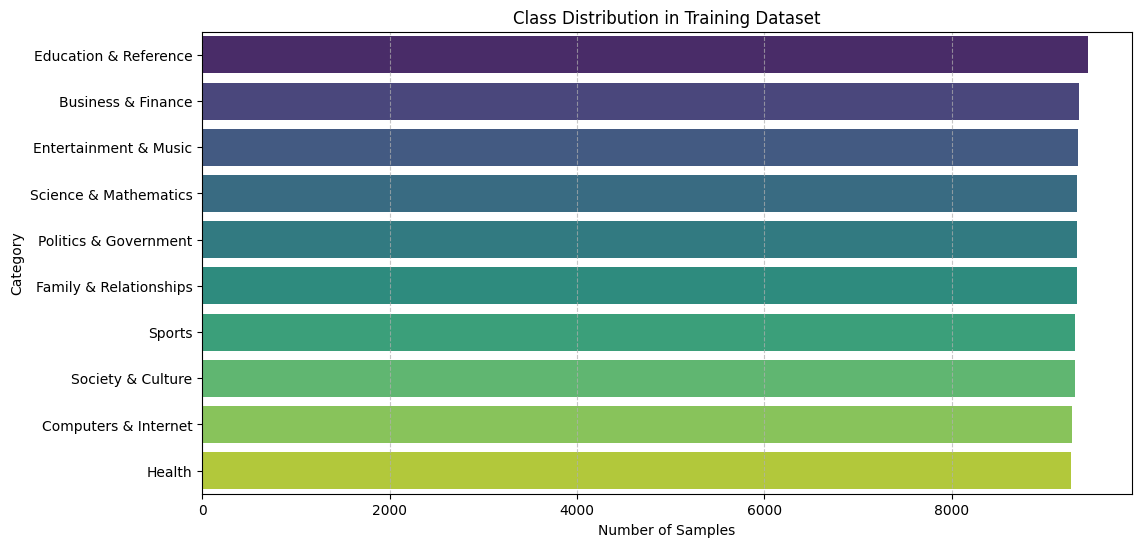


--- Text Statistics ---
         char_count    word_count
count  93333.000000  93333.000000
mean     631.583834    105.946096
std      570.352484     97.265285
min      126.000000     16.000000
25%      288.000000     46.000000
50%      452.000000     75.000000
75%      754.000000    129.000000
max     6984.000000   1256.000000


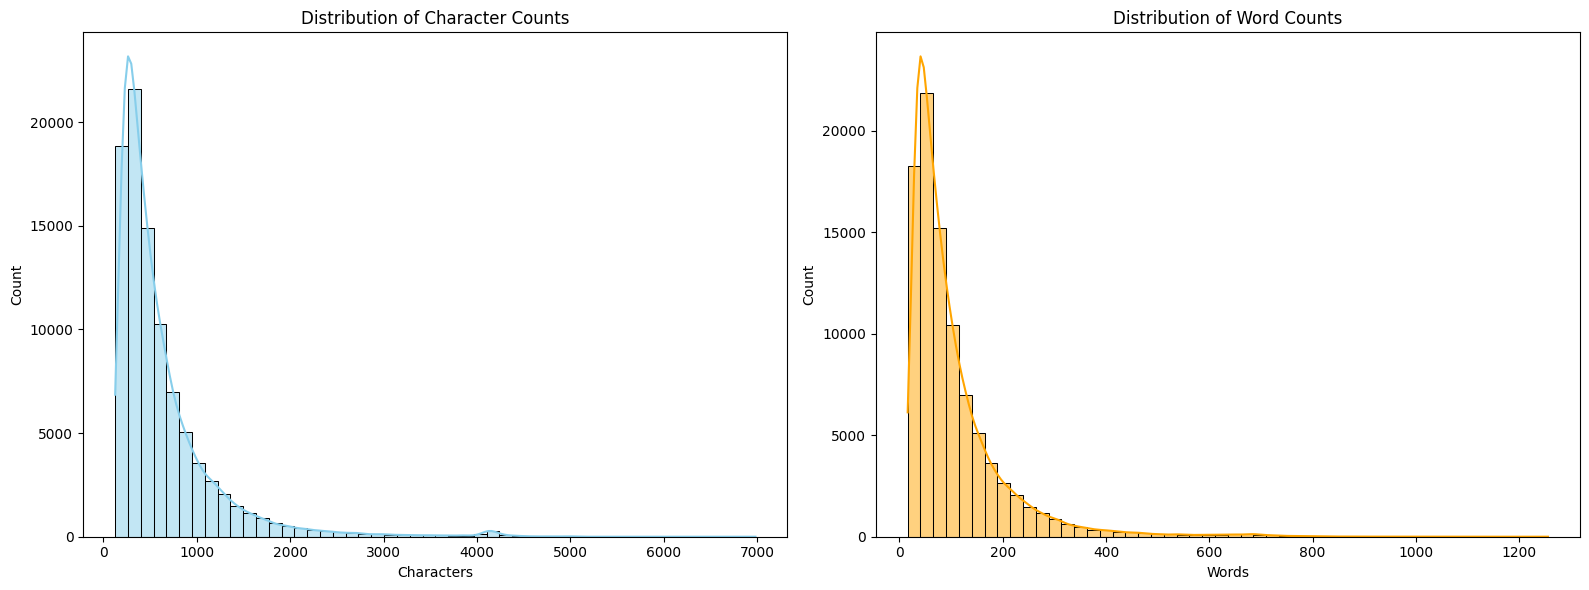

📊 Class Distribution Summary:
Class                | Count      | Percentage
--------------------------------------------------
Education & Reference | 9449       | 10.12%
Business & Finance   | 9354       | 10.02%
Entertainment & Music | 9342       | 10.01%
Science & Mathematics | 9339       | 10.01%
Politics & Government | 9339       | 10.01%
Family & Relationships | 9334       | 10.00%
Sports               | 9312       | 9.98%
Society & Culture    | 9309       | 9.97%
Computers & Internet | 9286       | 9.95%
Health               | 9269       | 9.93%


/tmp/ipython-input-3303481152.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y='Class', data=df_train, order=class_counts.index, palette='viridis')


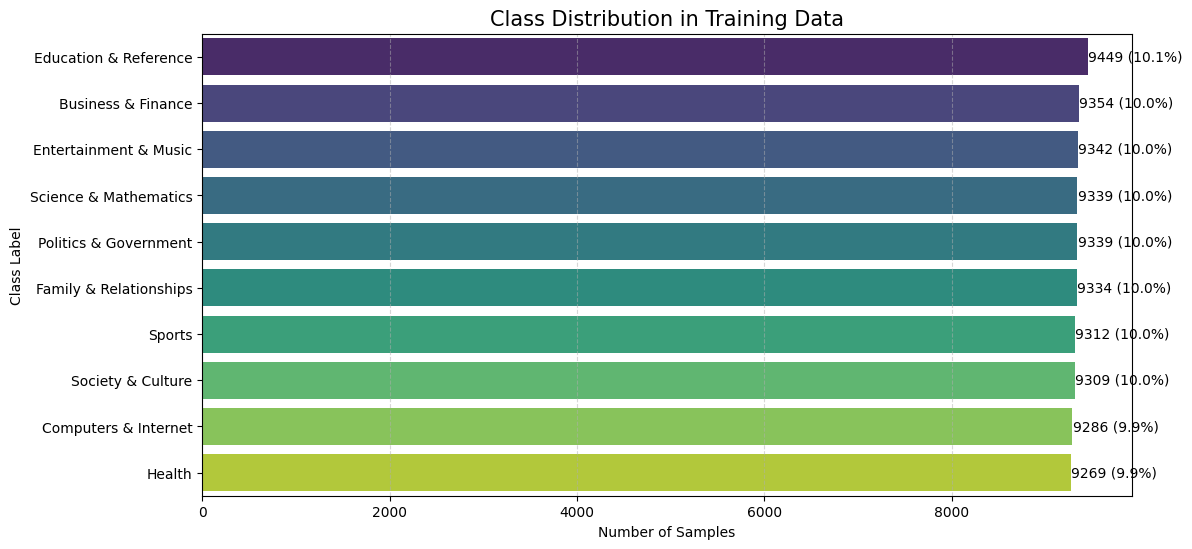

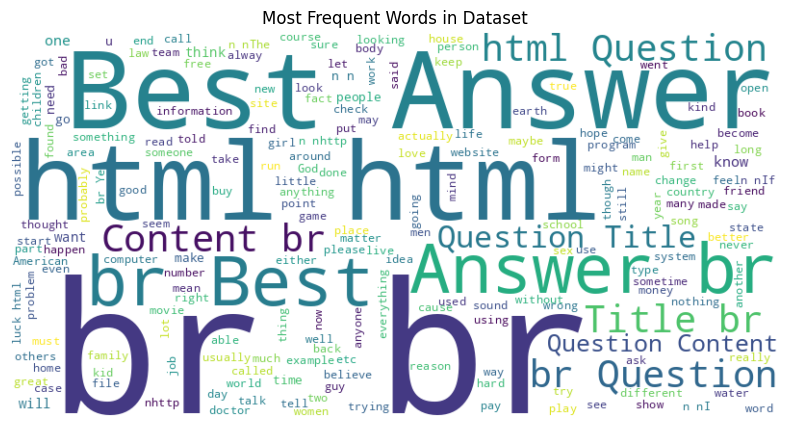

In [ ]:





# --- 2. EXPLORATORY DATA ANALYSIS (EDA) ---

# Check for missing values
print("\n--- Missing Values ---")
print(df_train.isnull().sum())

# A. Class Distribution Analysis
# This helps check if the dataset is balanced or imbalanced
plt.figure(figsize=(12, 6))
sns.countplot(y='Class', data=df_train, order=df_train['Class'].value_counts().index, palette='viridis')
plt.title('Class Distribution in Training Dataset')
plt.xlabel('Number of Samples')
plt.ylabel('Category')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# B. Text Length Analysis
# We calculate character and word counts to understand the verbosity of the text
df_train['char_count'] = df_train['QA Text'].apply(lambda x: len(str(x)))
df_train['word_count'] = df_train['QA Text'].apply(lambda x: len(str(x).split()))

print("\n--- Text Statistics ---")
print(df_train[['char_count', 'word_count']].describe())

# Plotting text length distributions
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df_train['char_count'], bins=50, ax=ax[0], color='skyblue', kde=True)
ax[0].set_title('Distribution of Character Counts')
ax[0].set_xlabel('Characters')

sns.histplot(df_train['word_count'], bins=50, ax=ax[1], color='orange', kde=True)
ax[1].set_title('Distribution of Word Counts')
ax[1].set_xlabel('Words')

plt.tight_layout()
plt.show()

# 1. Calculate Counts and Percentages
class_counts = df_train['Class'].value_counts()
class_percents = df_train['Class'].value_counts(normalize=True) * 100

# 2. Print Summary Table
print(" Class Distribution Summary:")
print(f"{'Class':<20} | {'Count':<10} | {'Percentage':<10}")
print("-" * 50)
for cls, count in class_counts.items():
    percent = class_percents[cls]
    print(f"{cls:<20} | {count:<10} | {percent:.2f}%")

# 3. Plot the Distribution
plt.figure(figsize=(12, 6))
ax = sns.countplot(y='Class', data=df_train, order=class_counts.index, palette='viridis')

# Add labels to the bars
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 5,       # x-position
             p.get_y() + p.get_height() / 2, # y-position
             f'{int(width)} ({width/len(df_train)*100:.1f}%)',
             va='center')

plt.title('Class Distribution in Training Data', fontsize=15)
plt.xlabel('Number of Samples')
plt.ylabel('Class Label')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

from wordcloud import WordCloud

# Combine all text into one giant string
all_text = " ".join(df_train['QA Text'].astype(str))

# Create Word Cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

# Plot
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Dataset')
plt.show()

#Preprocessing

In [ ]:
tf.keras.backend.clear_session()

In [ ]:
import time
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from nltk.stem import WordNetLemmatizer
print("--- 3. Preprocessing & Experimentation ---")

# Setup NLTK
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# --- TECHNIQUE 1: LIGHT CLEANING (Baseline) ---
def clean_light(text):
    if not isinstance(text, str): return ""
    text = html.unescape(text)               # Decode HTML
    text = re.sub(r'<[^>]+>', ' ', text)     # Remove Tags
    text = text.lower()                      # Lowercase
    return text

# --- TECHNIQUE 2: HEAVY CLEANING (Stopwords + Lemmatization) ---
def clean_heavy(text):
    if not isinstance(text, str): return ""
    # 1. Basic cleaning
    text = html.unescape(text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text) # Remove punctuation/numbers
    text = text.lower()

    # 2. Advanced processing
    tokens = text.split()
    # Remove stopwords and short words, then lemmatize
    cleaned = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return " ".join(cleaned)

# Apply both techniques
print("Applying Light Cleaning...")
df_train['text_light'] = df_train['QA Text'].apply(clean_light)

print("Applying Heavy Cleaning (this may take a moment)...")
df_train['text_heavy'] = df_train['QA Text'].apply(clean_heavy)

# --- EXPERIMENT: COMPARE ACCURACY ---
# We use a small slice of data and Naive Bayes for a quick check
print("\n--- Running Experiment: Light vs. Heavy Preprocessing ---")

# Prepare temporary labels
le_exp = LabelEncoder()
y_exp = le_exp.fit_transform(df_train['Class'])

# Function to evaluate a cleaning method
def evaluate_preprocessing(column_name):
    # Vectorize
    tfidf = TfidfVectorizer(max_features=5000)
    X = tfidf.fit_transform(df_train[column_name])

    # Split (Internal check)
    X_tr, X_val, y_tr, y_val = train_test_split(X, y_exp, test_size=0.2, random_state=42)

    # Train fast model
    model = MultinomialNB()
    model.fit(X_tr, y_tr)
    acc = accuracy_score(y_val, model.predict(X_val))
    return acc

acc_light = evaluate_preprocessing('text_light')
acc_heavy = evaluate_preprocessing('text_heavy')

print(f"Accuracy with Light Cleaning: {acc_light:.4f}")
print(f"Accuracy with Heavy Cleaning: {acc_heavy:.4f}")

# --- DECISION ---
if acc_heavy > acc_light:
    print("\n DECISION: 'Heavy Cleaning' performed better (or similar with less noise). We will use this.")
    final_clean_col = 'text_heavy'
    # Apply heavy cleaning to TEST set as well for the final phase
    df_test['clean_text'] = df_test['QA Text'].apply(clean_heavy)
    df_train['clean_text'] = df_train['text_heavy'] # Set as main column
else:
    print("\n DECISION: 'Light Cleaning' performed better. We will use this.")
    final_clean_col = 'text_light'
    df_test['clean_text'] = df_test['QA Text'].apply(clean_light)
    df_train['clean_text'] = df_train['text_light']

# Show the transformation
print(f"\nExample of Final Processed Text:\n{df_train['clean_text'].iloc[0][:200]}...")

--- 3. Preprocessing & Experimentation ---
Applying Light Cleaning...
Applying Heavy Cleaning (this may take a moment)...

--- Running Experiment: Light vs. Heavy Preprocessing ---
Accuracy with Light Cleaning: 0.6543
Accuracy with Heavy Cleaning: 0.6610

✅ DECISION: 'Heavy Cleaning' performed better (or similar with less noise). We will use this.

Example of Final Processed Text:
question title sleeping contactswhy hurt bad next couple day even contact arent question content slept contact accidentally woke took outmy eye hurt badwhen put back eye still hurt badi currently cont...


#Label Encoding




In [ ]:
tf.keras.backend.clear_session()
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Initialize and Fit
le = LabelEncoder()
y_train = le.fit_transform (df_train['Class'])
y_test = le.transform(df_test['Class'])



print(" Labels Encoded:", list(le.classes_))

✅ Labels Encoded: ['Business & Finance', 'Computers & Internet', 'Education & Reference', 'Entertainment & Music', 'Family & Relationships', 'Health', 'Politics & Government', 'Science & Mathematics', 'Society & Culture', 'Sports']


#Word represtation


In [ ]:
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from gensim.models import Word2Vec

print("--- GENERATING ALL WORD REPRESENTATIONS ---")


print("\n1. Generating Bag of Words & TF-IDF...")

# A. Bag of Words (CountVectorizer)
# Creates a matrix of token counts
bow_vectorizer = CountVectorizer(max_features=5000)
X_train_bow = bow_vectorizer.fit_transform(df_train['clean_text'])
X_test_bow = bow_vectorizer.transform(df_test['clean_text'])
print(f"✅ Bag of Words created. Shape: {X_train_bow.shape}")

# B. TF-IDF (Term Frequency - Inverse Document Frequency)
# Creates a matrix of weighted importance
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(df_train['clean_text'])
X_test_tfidf = tfidf_vectorizer.transform(df_test['clean_text'])
print(f"✅ TF-IDF created. Shape: {X_train_tfidf.shape}")



print("\n2. Generating Word Embeddings (CBOW, Skip-gram, Keras)...")

# --- Setup: Tokenization & Padding ---
# Neural Networks require integer sequences, not raw text
MAX_VOCAB = 20000
MAX_LEN = 200
EMBEDDING_DIM = 100

tokenizer = Tokenizer(num_words=MAX_VOCAB)
tokenizer.fit_on_texts(df_train['clean_text'])
vocab_size = len(tokenizer.word_index) + 1

# Convert text to sequences
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(df_train['clean_text']), maxlen=MAX_LEN)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(df_test['clean_text']), maxlen=MAX_LEN)

# Prepare sentences for Gensim Word2Vec training
sentences = [text.split() for text in df_train['clean_text']]

# --- C. CBOW (Continuous Bag of Words) ---
# Predicts target word from context (fast)
print("  > Training CBOW (sg=0)...")
w2v_cbow = Word2Vec(sentences, vector_size=EMBEDDING_DIM, window=5, min_count=2, sg=0, workers=4)

# --- D. Skip-gram ---
# Predicts context from target word (better for rare words)
print("  > Training Skip-gram (sg=1)...")
w2v_skip = Word2Vec(sentences, vector_size=EMBEDDING_DIM, window=5, min_count=2, sg=1, workers=4)

# --- E. Create Embedding Matrices ---
# This maps the Gensim weights to a format Keras can use
def create_embedding_matrix(model_wv):
    matrix = np.zeros((vocab_size, EMBEDDING_DIM))
    for word, i in tokenizer.word_index.items():
        if word in model_wv:
            matrix[i] = model_wv[word]

    return matrix

matrix_cbow = create_embedding_matrix(w2v_cbow.wv)
matrix_skip = create_embedding_matrix(w2v_skip.wv)

print(f" CBOW Matrix created. Shape: {matrix_cbow.shape}")
print(f" Skip-gram Matrix created. Shape: {matrix_skip.shape}")
print(" Keras Embedding is ready (will be initialized in the model layer).")

print("\n--- ALL REPRESENTATIONS COMPLETE ---")

--- GENERATING ALL WORD REPRESENTATIONS ---

1. Generating Bag of Words & TF-IDF...
✅ Bag of Words created. Shape: (93333, 5000)
✅ TF-IDF created. Shape: (93333, 5000)

2. Generating Word Embeddings (CBOW, Skip-gram, Keras)...
  > Training CBOW (sg=0)...
  > Training Skip-gram (sg=1)...
✅ CBOW Matrix created. Shape: (283941, 100)
✅ Skip-gram Matrix created. Shape: (283941, 100)
✅ Keras Embedding is ready (will be initialized in the model layer).

--- ALL REPRESENTATIONS COMPLETE ---


#All models


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN, GRU, LSTM, Bidirectional, Embedding, GlobalAveragePooling1D, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping

# ==========================================
# 0. HYPERPARAMETER TUNING (MANUAL)
# ==========================================
# Change these values to "tune" your models as requested
HP = {
    'epochs': 10,           # How long to train
    'batch_size': 64,       # Size of data chunks
    'dense_units': 128,     # Neurons in Dense layers
    'rnn_units': 64,        # Neurons in RNN/GRU/LSTM layers
    'dropout_rate': 0.3,    # Dropout to prevent overfitting
    'patience': 3           # Early Stopping trigger
}

# Store all results here
experiment_results = {}
prediction={}

logistic regression

In [ ]:

print("\n=== TRACK A: TF-IDF EXPERIMENTS ===")

# --- Experiment 1: ML Model (Logistic Regression) ---
print("\n--- Tuning Logistic Regression ---")

C_values = [0.01, 0.1, 1, 10, 100]
best_acc = 0
best_c = 0

for c_val in C_values:
    # Initialize model with specific C
    model = LogisticRegression(C=c_val, max_iter=1000, solver='liblinear')

    # Train
    model.fit(X_train_tfidf, y_train)

    # Evaluate
    acc = accuracy_score(y_test, model.predict(X_test_tfidf))
    print(f"C={c_val}: Accuracy = {acc:.4f}")

    # Track Best
    if acc > best_acc:
        best_acc = acc
        best_c = c_val

print(f"\n Best C value: {best_c} with Accuracy: {best_acc:.4f}")

..

print(f"\n Best C value: {best_c} with Accuracy: {best_acc:.4f}")

# Re-initialize and Re-fit the final model using the best C found
best_model = LogisticRegression(C=best_c, max_iter=1000, solver='liblinear')
best_model.fit(X_train_tfidf, y_train)
prediction["logisticRegression"]=best_acc
# return best_model


=== TRACK A: TF-IDF EXPERIMENTS ===

--- Tuning Logistic Regression ---
C=0.01: Accuracy = 0.6193
C=0.1: Accuracy = 0.6574
C=1: Accuracy = 0.6747
C=10: Accuracy = 0.6631
C=100: Accuracy = 0.6477

✅ Best C value: 1 with Accuracy: 0.6747

✅ Best C value: 1 with Accuracy: 0.6747



=== Classification Report (Logistic Regression) ===
              precision    recall  f1-score   support

           0       0.56      0.48      0.52      6000
           1       0.79      0.84      0.81      6000
           2       0.52      0.47      0.50      6000
           3       0.64      0.64      0.64      6000
           4       0.67      0.75      0.71      5999
           5       0.72      0.78      0.74      6000
           6       0.74      0.74      0.74      6000
           7       0.66      0.72      0.69      6000
           8       0.58      0.53      0.55      6000
           9       0.82      0.81      0.81      6000

    accuracy                           0.67     59999
   macro avg       0.67      0.67      0.67     59999
weighted avg       0.67      0.67      0.67     59999



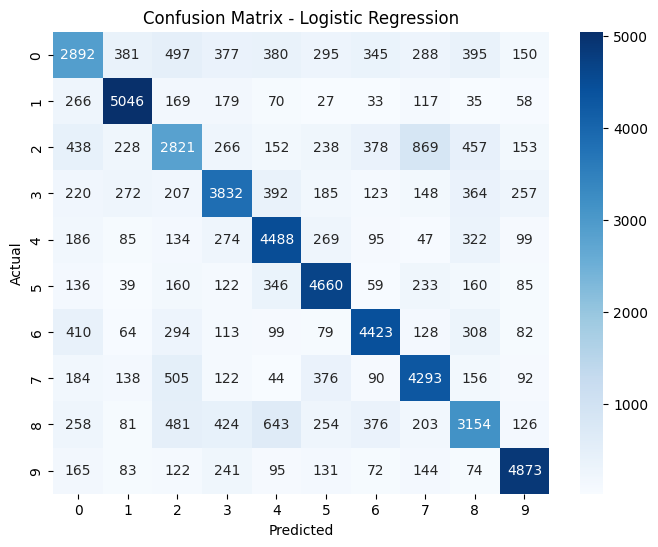

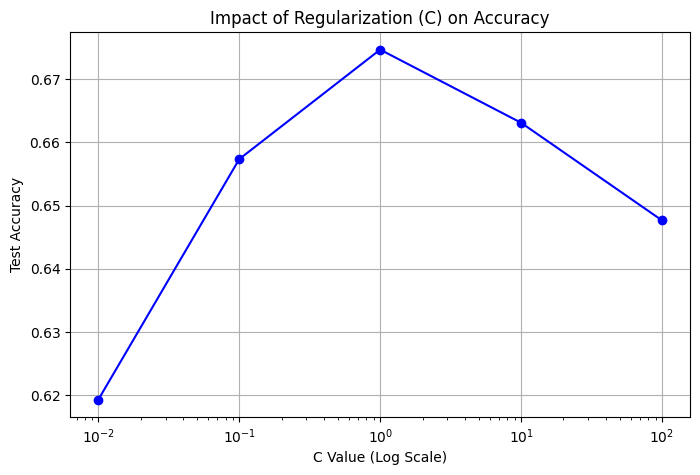

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Generate Predictions
y_pred_logreg = best_model.predict(X_test_tfidf)

# 2. Print Classification Report
print("\n=== Classification Report (Logistic Regression) ===")
print(classification_report(y_test, y_pred_logreg))

# 3. Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred_logreg)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=best_model.classes_,
            yticklabels=best_model.classes_)
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


# --- Modified Loop to Store and Plot Results ---
C_values = [0.01, 0.1, 1, 10, 100]
acc_scores = []

print("Collecting scores for plotting...")

for c_val in C_values:
    # Train temp model
    temp_model = LogisticRegression(C=c_val, max_iter=1000, solver='liblinear')
    temp_model.fit(X_train_tfidf, y_train)

    # Store Score
    score = accuracy_score(y_test, temp_model.predict(X_test_tfidf))
    acc_scores.append(score)

# --- Plotting the Hyperparameter Curve ---
plt.figure(figsize=(8, 5))
plt.plot(C_values, acc_scores, marker='o', linestyle='-', color='b')
plt.xscale('log') # Log scale because C varies by powers of 10
plt.title('Impact of Regularization (C) on Accuracy')
plt.xlabel('C Value (Log Scale)')
plt.ylabel('Test Accuracy')
plt.grid(True)
plt.show()

DNN (TF-IDF)

In [ ]:
#hp tunning 1

# ==========================================
# TRACK A: DNN TF-IDF EXPERIMENTS



print("Running Exp 2: TF-IDF + DNN...")
tuned_HP = {

    'epochs': 15,           # Increased epochs

    'batch_size': 32,       # Smaller batch size for better generalization

    'dropout_rate': 0.4,    # slightly higher dropout

    'patience': 4           # Wait longer before stopping

}



early_stop_tuned = EarlyStopping(monitor='val_loss', patience=tuned_HP['patience'], restore_best_weights=True)



def build_tuned_tfidf_dnn():

    model = Sequential([

        # Layer 1: Wider (512 neurons) to capture more TF-IDF patterns

        Dense(512, activation='relu', input_shape=(X_train_tfidf.shape[1],)),

        Dropout(tuned_HP['dropout_rate']),



        # Layer 2: Narrower

        Dense(256, activation='relu'),

        Dropout(tuned_HP['dropout_rate']),



        # Layer 3: Extra hidden layer for deeper learning

        Dense(128, activation='relu'),

        Dropout(tuned_HP['dropout_rate']),



        # Output Layer

        Dense(len(le.classes_), activation='softmax')

    ])

    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

    return model



model_dnn_tuned = build_tuned_tfidf_dnn()



print(f"Training with Tuned Parameters: {tuned_HP}")





history_tuned = model_dnn_tuned.fit(

    X_train_tfidf.toarray(), y_train,

    epochs=15,

    batch_size=64,

    validation_split=0.1,

    callbacks=[early_stop_tuned],

    verbose=1

)

model_dnn_tuned.summary()

# Evaluate

acc_tuned = model_dnn_tuned.evaluate(X_test_tfidf.toarray(), y_test, verbose=0)[1]



Running Exp 2: TF-IDF + DNN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training with Tuned Parameters: {'epochs': 15, 'batch_size': 32, 'dropout_rate': 0.4, 'patience': 4}
Epoch 1/15
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.5166 - loss: 1.4766 - val_accuracy: 0.6708 - val_loss: 1.0382
Epoch 2/15
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7103 - loss: 0.9374 - val_accuracy: 0.6664 - val_loss: 1.0340
Epoch 3/15
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7617 - loss: 0.7733 - val_accuracy: 0.6606 - val_loss: 1.0856
Epoch 4/15
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8108 - loss: 0.6037 - val_accuracy: 0.6546 - val_loss: 1.1748
Epoch 5/15
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8651 - loss: 0.4301 - val_accuracy: 0.6489 - val_loss: 1.3187
Epoch 6/15
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9047 - loss: 0.3044 - val_accuracy: 0.6435 - val_loss: 1.4874


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     2,560,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,178,080 (31.20 MB)

 Trainable params: 2,726,026 (10.40 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,452,054 (20.80 MB)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


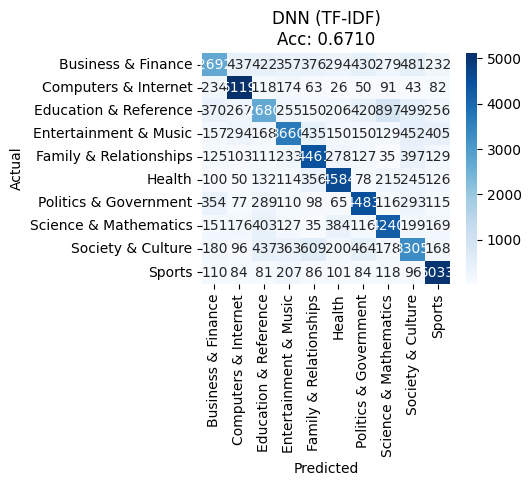

                        precision    recall  f1-score   support

    Business & Finance       0.60      0.45      0.51      6000
  Computers & Internet       0.76      0.85      0.81      6000
 Education & Reference       0.55      0.45      0.49      6000
 Entertainment & Music       0.65      0.61      0.63      6000
Family & Relationships       0.67      0.74      0.70      5999
                Health       0.73      0.76      0.75      6000
 Politics & Government       0.70      0.75      0.72      6000
 Science & Mathematics       0.67      0.71      0.69      6000
     Society & Culture       0.55      0.55      0.55      6000
                Sports       0.75      0.84      0.79      6000

              accuracy                           0.67     59999
             macro avg       0.66      0.67      0.67     59999
          weighted avg       0.66      0.67      0.67     59999



In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import numpy as np
preds = model_dnn_tuned.predict(X_test_tfidf.toarray())
dnn_pred = np.argmax(preds, axis=1)

cm = confusion_matrix(y_test, dnn_pred)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=le.classes_, yticklabels=le.classes_)
name="DNN (TF-IDF)"
plt.title(f"{name}\nAcc: {acc_tuned:.4f}")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()
print(classification_report(y_test, dnn_pred, target_names=le.classes_))


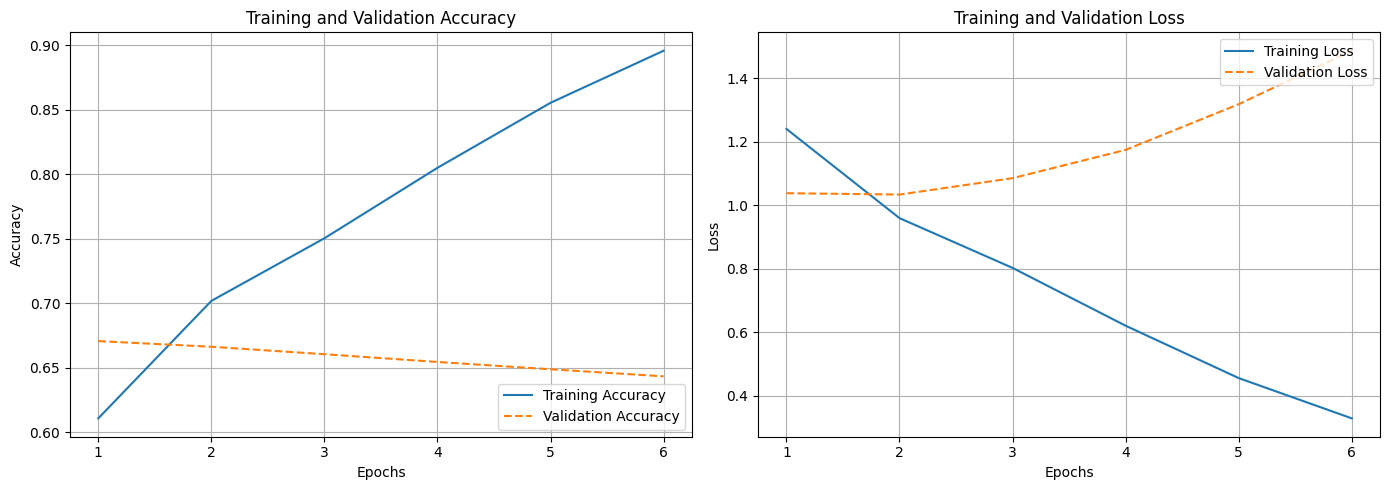

In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    # Extract values from the history object
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    # Set up the figure
    plt.figure(figsize=(14, 5))

    # 1. Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linestyle='--')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    # 2. Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss', linestyle='--')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Run the plotting function
plot_training_history(history_tuned)

In [ ]:
#hp tuning 2
from tensorflow.keras.layers import BatchNormalization, LeakyReLU
from tensorflow.keras.callbacks import ReduceLROnPlateau

print("Running Exp 2 (Option 1): Batch Norm + LR Scheduler...")

# Hyperparameters
hp_opt1 = {
    'epochs': 30,             # Give it more time, EarlyStopping will cut it off
    'batch_size': 32,         # Smaller batch = more updates per epoch
    'dropout_rate': 0.3,      # Slightly lower dropout because Batch Norm adds some regularization
    'patience': 5
}

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=hp_opt1['patience'], restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6, verbose=1)

def build_dnn_opt1():
    model = Sequential([
        # Layer 1
        Dense(512, input_shape=(X_train_tfidf.shape[1],)),
        BatchNormalization(),        # <--- Added
        LeakyReLU(alpha=0.1),        # <--- Advanced Activation
        Dropout(hp_opt1['dropout_rate']),

        # Layer 2
        Dense(256),
        BatchNormalization(),        # <--- Added
        LeakyReLU(alpha=0.1),
        Dropout(hp_opt1['dropout_rate']),

        # Layer 3
        Dense(128),
        BatchNormalization(),        # <--- Added
        LeakyReLU(alpha=0.1),
        Dropout(hp_opt1['dropout_rate']),

        # Output
        Dense(len(le.classes_), activation='softmax')
    ])

    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

model_opt1 = build_dnn_opt1()

history_opt1 = model_opt1.fit(
    X_train_tfidf.toarray(), y_train,
    epochs=hp_opt1['epochs'],
    batch_size=hp_opt1['batch_size'],
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr], # Added ReduceLROnPlateau
    verbose=1
)
model_opt1.summary()

# Evaluate

acc_tuned_1= model_opt1.evaluate(X_test_tfidf.toarray(), y_test, verbose=0)[1]

print(f"✅ Tuned DNN Accuracy: {acc_tuned_1:.4f}")



# Save to your results dictionary

experiment_results['2. TF-IDF + DNN (Tuned)'] = acc_tuned_1

Running Exp 2 (Option 1): Batch Norm + LR Scheduler...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/30
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.5457 - loss: 1.4230 - val_accuracy: 0.6662 - val_loss: 1.0390 - learning_rate: 0.0010
Epoch 2/30
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.6878 - loss: 0.9792 - val_accuracy: 0.6652 - val_loss: 1.0339 - learning_rate: 0.0010
Epoch 3/30
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7208 - loss: 0.8635 - val_accuracy: 0.6617 - val_loss: 1.0473 - learning_rate: 0.0010
Epoch 4/30
2612/2625 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7471 - loss: 0.7704
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.7470 - loss: 0.7706 - val_accuracy: 0.6610 - val_loss: 1.0897 - learning_rate: 0.0010
Epoch 5/30
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7884 - loss: 0.6310 - val_accuracy: 0.6641 - val_loss: 1.1814 - learning_rate: 2.0000e-04
Epoch 6/30
2614/2625 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │     2,560,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,185,248 (31.22 MB)

 Trainable params: 2,727,818 (10.41 MB)

 Non-trainable params: 1,792 (7.00 KB)

 Optimizer params: 5,455,638 (20.81 MB)

✅ Tuned DNN Accuracy: 0.6658


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


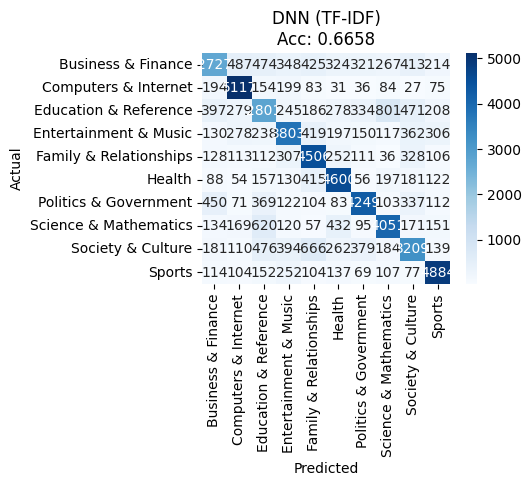

                        precision    recall  f1-score   support

    Business & Finance       0.60      0.45      0.52      6000
  Computers & Internet       0.75      0.85      0.80      6000
 Education & Reference       0.50      0.47      0.48      6000
 Entertainment & Music       0.64      0.63      0.64      6000
Family & Relationships       0.65      0.75      0.70      5999
                Health       0.70      0.77      0.73      6000
 Politics & Government       0.73      0.71      0.72      6000
 Science & Mathematics       0.68      0.68      0.68      6000
     Society & Culture       0.58      0.53      0.55      6000
                Sports       0.77      0.81      0.79      6000

              accuracy                           0.67     59999
             macro avg       0.66      0.67      0.66     59999
          weighted avg       0.66      0.67      0.66     59999



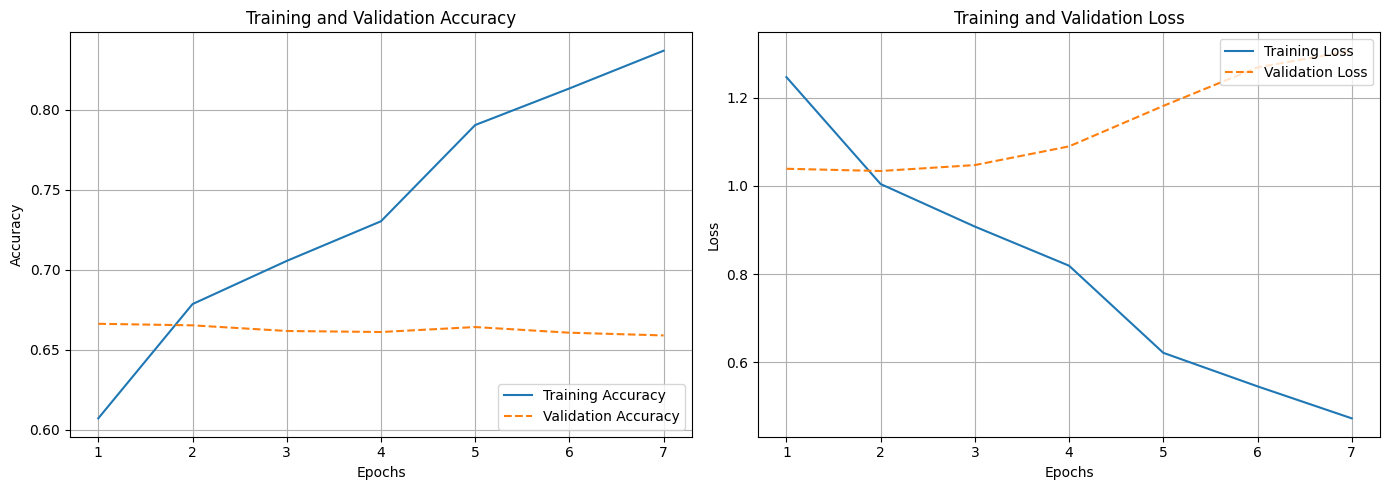

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import numpy as np
preds = model_opt1.predict(X_test_tfidf.toarray())
dnn_pred_1 = np.argmax(preds, axis=1)

cm = confusion_matrix(y_test, dnn_pred_1)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=le.classes_, yticklabels=le.classes_)
name="DNN (TF-IDF)"
plt.title(f"{name}\nAcc: {acc_tuned_1:.4f}")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


classificationn_report = classification_report(y_test, dnn_pred_1, target_names=le.classes_)
print(classificationn_report)
import matplotlib.pyplot as plt

def plot_training_history(history):
    # Extract values from the history object
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    # Set up the figure
    plt.figure(figsize=(14, 5))

    # 1. Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linestyle='--')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    # 2. Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss', linestyle='--')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Run the plotting function
plot_training_history(history_opt1)

In [ ]:
#hp tuning 3
tf.keras.backend.clear_session()
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

print("Running Exp 2 (Option 2): L2 Regularization + Low LR...")

# Hyperparameters
hp_opt2 = {
    'epochs': 40,            # Needs more epochs because Learning Rate is low
    'batch_size': 64,        # Standard batch size for stability
    'dropout_rate': 0.4,
    'l2_penalty': 0.001,     # Strength of regularization
    'learning_rate': 1e-4    # Slower, more precise learning
}

early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

def build_dnn_opt2():
    model = Sequential([
        # Layer 1: Wider but constrained
        Dense(1024, activation='relu', kernel_regularizer=l2(hp_opt2['l2_penalty']), input_shape=(X_train_tfidf.shape[1],)),
        Dropout(hp_opt2['dropout_rate']),

        # Layer 2
        Dense(512, activation='relu', kernel_regularizer=l2(hp_opt2['l2_penalty'])),
        Dropout(hp_opt2['dropout_rate']),

        # Layer 3
        Dense(256, activation='relu', kernel_regularizer=l2(hp_opt2['l2_penalty'])),
        Dropout(hp_opt2['dropout_rate']),

        # Output
        Dense(len(le.classes_), activation='softmax')
    ])

    # Custom Optimizer
    opt = Adam(learning_rate=hp_opt2['learning_rate'])

    model.compile(loss='sparse_categorical_crossentropy', optimizer=opt, metrics=['accuracy'])
    return model

model_opt2 = build_dnn_opt2()

history_opt2 = model_opt2.fit(
    X_train_tfidf.toarray(), y_train,
    epochs=hp_opt2['epochs'],
    batch_size=hp_opt2['batch_size'],
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)
model_opt2.summary()

# Evaluate

acc_tuned_2= model_opt2.evaluate(X_test_tfidf.toarray(), y_test, verbose=0)[1]

print(f"✅ Tuned DNN Accuracy: {acc_tuned_2:.4f}")



# Save to your results dictionary

experiment_results['2. TF-IDF + DNN (Tuned)'] = acc_tuned_2

Running Exp 2 (Option 2): L2 Regularization + Low LR...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.3288 - loss: 3.1167 - val_accuracy: 0.6590 - val_loss: 1.5374
Epoch 2/40
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6539 - loss: 1.5285 - val_accuracy: 0.6665 - val_loss: 1.4155
Epoch 3/40
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6737 - loss: 1.3950 - val_accuracy: 0.6635 - val_loss: 1.3658
Epoch 4/40
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6816 - loss: 1.3277 - val_accuracy: 0.6627 - val_loss: 1.3435
Epoch 5/40
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6867 - loss: 1.2943 - val_accuracy: 0.6657 - val_loss: 1.3216
Epoch 6/40
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6933 - loss: 1.2593 - val_accuracy: 0.6631 - val_loss: 1.3130
Epoch 7/40
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6939 - loss: 1.2436 - val_accuracy: 0.6671 - val_loss: 1.3034
Epoch 8/40
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6999 - loss: 1.2294 -

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1024)           │     5,121,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,339,168 (66.14 MB)

 Trainable params: 5,779,722 (22.05 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 11,559,446 (44.10 MB)

✅ Tuned DNN Accuracy: 0.6673


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


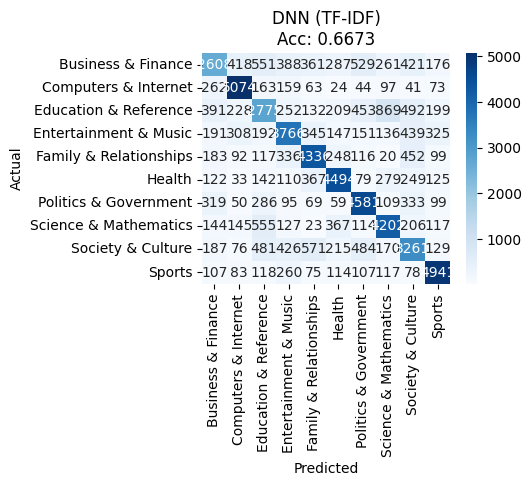

                        precision    recall  f1-score   support

    Business & Finance       0.58      0.43      0.50      6000
  Computers & Internet       0.78      0.85      0.81      6000
 Education & Reference       0.52      0.46      0.49      6000
 Entertainment & Music       0.64      0.63      0.63      6000
Family & Relationships       0.68      0.72      0.70      5999
                Health       0.73      0.75      0.74      6000
 Politics & Government       0.69      0.76      0.72      6000
 Science & Mathematics       0.67      0.70      0.69      6000
     Society & Culture       0.55      0.54      0.54      6000
                Sports       0.79      0.82      0.80      6000

              accuracy                           0.67     59999
             macro avg       0.66      0.67      0.66     59999
          weighted avg       0.66      0.67      0.66     59999



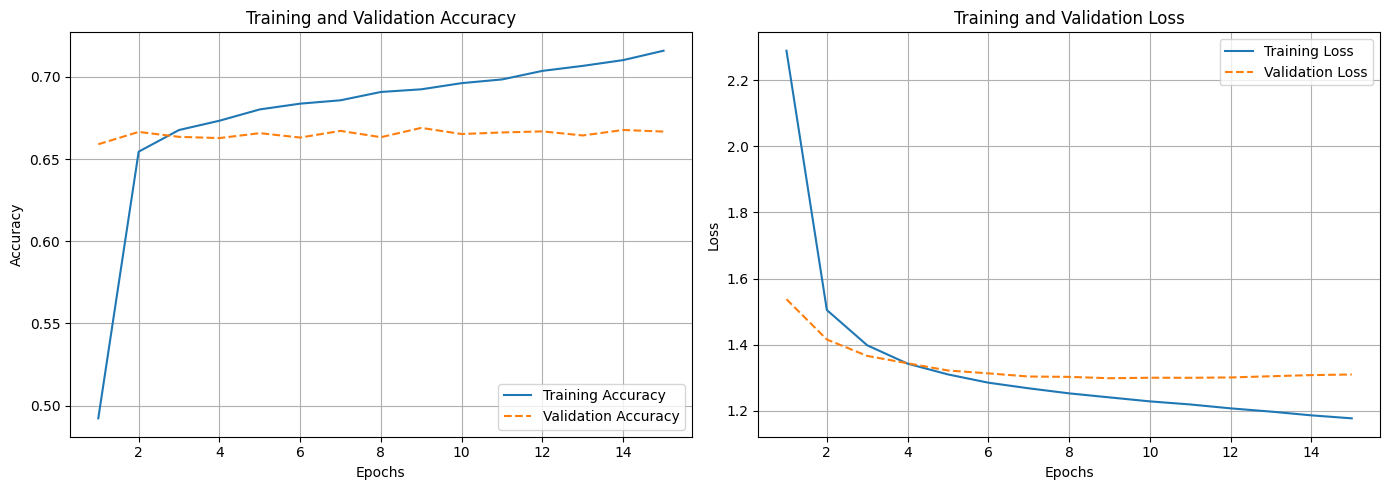

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import numpy as np
preds = model_opt2.predict(X_test_tfidf.toarray())
dnn_pred_2 = np.argmax(preds, axis=1)

cm = confusion_matrix(y_test, dnn_pred_2)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=le.classes_, yticklabels=le.classes_)
name="DNN (TF-IDF)"
plt.title(f"{name}\nAcc: {acc_tuned_2:.4f}")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


classificationn_report = classification_report(y_test, dnn_pred_2, target_names=le.classes_)
print(classificationn_report)
import matplotlib.pyplot as plt

def plot_training_history(history):
    # Extract values from the history object
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    # Set up the figure
    plt.figure(figsize=(14, 5))

    # 1. Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linestyle='--')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    # 2. Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss', linestyle='--')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Run the plotting function
plot_training_history(history_opt2)

In [ ]:
#store the highest accuracy
accc=[acc_tuned,acc_tuned_1,acc_tuned_2]
accc.sort()
prediction["DNN (TF-IDF)"]=accc[-1]
print(accc[-1])
prediction

0.6709612011909485


{'logisticRegression': 0.6747112451874198,
 'DNN (TF-IDF)': 0.6709612011909485,
 'DNN': 0.6890948414802551,
 'RNN': 0.527675449848175,
 'GRU': 0.7026616930961609,
 'LSTM': 0.6929782032966614,
 'Bi-RNN': 0.5946599245071411,
 'Bi-GRU': 0.7144119143486023,
 'Bi-LSTM': 0.712228536605835}

In [ ]:
tf.keras.backend.clear_session()

DNN (SkipGram)

In [ ]:
# hp tuning 1
from tensorflow.keras.callbacks import EarlyStopping
if 'experiment_results' not in locals():
    experiment_results = {}


HP = {
    'epochs': 10,
    'batch_size': 64,
    'dense_units': 128,
    'rnn_units': 64,
    'dropout_rate': 0.3,
    'patience': 3
}

from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=HP['patience'], restore_best_weights=True)
print("\n--- Running Exp 3: Skip-gram + DNN ---")

model_dnn = Sequential([
    Embedding(vocab_size, 100, weights=[matrix_skip], input_length=200, trainable=False),
    GlobalAveragePooling1D(),  # Flattens the sequence
    Dense(HP['dense_units'], activation='relu'),
    Dropout(HP['dropout_rate']),
    Dense(len(le.classes_), activation='softmax')
])

model_dnn.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history_dnn = model_dnn.fit(
    X_train_seq, y_train,
    epochs=HP['epochs'], batch_size=HP['batch_size'],
    validation_split=0.1, callbacks=[early_stop], verbose=1
)
model_dnn.summary()
acc = model_dnn.evaluate(X_test_seq, y_test, verbose=0)[1]
experiment_results['3. Skip-gram + DNN'] = acc
print(f"✅ Accuracy: {acc:.4f}")


--- Running Exp 3: Skip-gram + DNN ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.4477 - loss: 1.8747 - val_accuracy: 0.6370 - val_loss: 1.2683
Epoch 2/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6140 - loss: 1.2790 - val_accuracy: 0.6420 - val_loss: 1.1437
Epoch 3/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6359 - loss: 1.1747 - val_accuracy: 0.6579 - val_loss: 1.0922
Epoch 4/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6387 - loss: 1.1451 - val_accuracy: 0.6605 - val_loss: 1.0671
Epoch 5/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6481 - loss: 1.1165 - val_accuracy: 0.6638 - val_loss: 1.0555
Epoch 6/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6535 - loss: 1.0934 - val_accuracy: 0.6633 - val_loss: 1.0447
Epoch 7/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6564 - loss: 1.0817 - val_accuracy: 0.6680 - val_loss: 1.0339
Epoch 8/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6542 - loss: 1.0836 - 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 100)       │    28,394,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 100)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,436,756 (108.48 MB)

 Trainable params: 14,218 (55.54 KB)

 Non-trainable params: 28,394,100 (108.31 MB)

 Optimizer params: 28,438 (111.09 KB)

✅ Accuracy: 0.6721


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


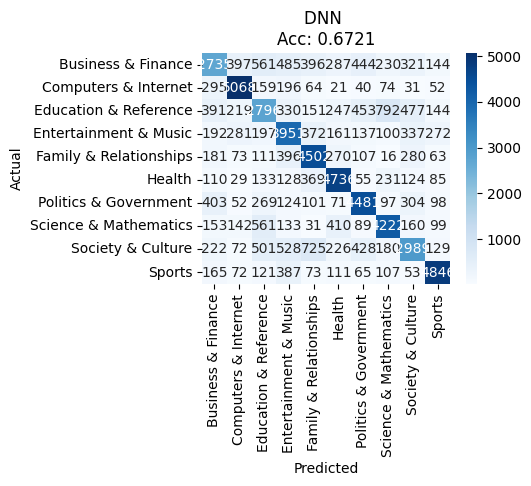

                        precision    recall  f1-score   support

    Business & Finance       0.56      0.46      0.50      6000
  Computers & Internet       0.79      0.84      0.82      6000
 Education & Reference       0.52      0.47      0.49      6000
 Entertainment & Music       0.59      0.66      0.62      6000
Family & Relationships       0.66      0.75      0.70      5999
                Health       0.72      0.79      0.76      6000
 Politics & Government       0.71      0.75      0.73      6000
 Science & Mathematics       0.70      0.70      0.70      6000
     Society & Culture       0.59      0.50      0.54      6000
                Sports       0.82      0.81      0.81      6000

              accuracy                           0.67     59999
             macro avg       0.67      0.67      0.67     59999
          weighted avg       0.67      0.67      0.67     59999



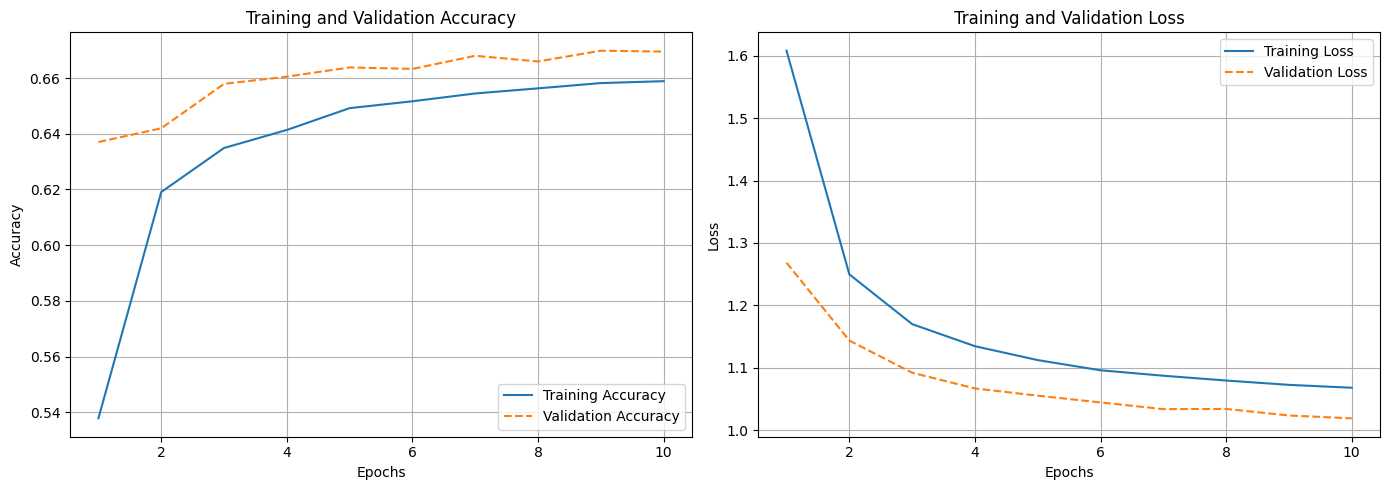

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import numpy as np
preds = model_dnn.predict(X_test_seq)
dnn_pred = np.argmax(preds, axis=1)

cm = confusion_matrix(y_test, dnn_pred)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=le.classes_, yticklabels=le.classes_)
name="DNN "
plt.title(f"{name}\nAcc: {acc:.4f}")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


classificationn_report = classification_report(y_test, dnn_pred, target_names=le.classes_)
print(classificationn_report)
import matplotlib.pyplot as plt

def plot_training_history(history):
    # Extract values from the history object
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    # Set up the figure
    plt.figure(figsize=(14, 5))

    # 1. Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linestyle='--')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    # 2. Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss', linestyle='--')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Run the plotting function
plot_training_history(history_dnn)

In [ ]:
tf.keras.backend.clear_session()
from tensorflow.keras.optimizers import Adam
# hp tunning 2
print("\n--- Running Exp 3 (Option 1): Fine-Tuned Embeddings + Deeper Net ---")


HP_opt1 = {
    'epochs': 15,            # Needs more time to adjust embeddings
    'batch_size': 32,        # Smaller batch for more granular updates
    'learning_rate': 1e-4,   # LOW learning rate is crucial when fine-tuning!
    'dropout_rate': 0.4
}

model_dnn_1 = Sequential([

    Embedding(vocab_size, 100, weights=[matrix_skip], input_length=200, trainable=True),

    GlobalAveragePooling1D(),


    Dense(256, activation='relu'),
    Dropout(HP_opt1['dropout_rate']),

    Dense(128, activation='relu'),
    Dropout(HP_opt1['dropout_rate']),

    Dense(len(le.classes_), activation='softmax')
])

# Use custom optimizer with lower learning rate
optimizer = Adam(learning_rate=HP_opt1['learning_rate'])

model_dnn_1.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

history_1 = model_dnn_1.fit(
    X_train_seq, y_train,
    epochs=HP_opt1['epochs'],
    batch_size=HP_opt1['batch_size'],
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)
model_dnn_1.summary()
acc_1= model_dnn_1.evaluate(X_test_seq, y_test, verbose=0)[1]
experiment_results['3. Skip-gram + DNN'] = acc_1
print(f"✅ Accuracy: {acc_1:.4f}")


--- Running Exp 3 (Option 1): Fine-Tuned Embeddings + Deeper Net ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/15
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - accuracy: 0.2742 - loss: 2.1202 - val_accuracy: 0.5939 - val_loss: 1.4492
Epoch 2/15
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.5434 - loss: 1.4602 - val_accuracy: 0.6343 - val_loss: 1.2252
Epoch 3/15
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.6000 - loss: 1.2805 - val_accuracy: 0.6512 - val_loss: 1.1470
Epoch 4/15
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.6236 - loss: 1.2028 - val_accuracy: 0.6570 - val_loss: 1.1032
Epoch 5/15
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.6393 - loss: 1.1430 - val_accuracy: 0.6672 - val_loss: 1.0678
Epoch 6/15
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.6594 - loss: 1.0926 - val_accuracy: 0.6657 - val_loss: 1.0497
Epoch 7/15
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.6621 - loss: 1.0709 - val_accuracy: 0.6669 - val_loss: 1.0373
Epoch 8/15
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.6724 - loss: 1

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 100)       │    28,394,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 100)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,362,428 (325.63 MB)

 Trainable params: 28,454,142 (108.54 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 56,908,286 (217.09 MB)

✅ Accuracy: 0.6891


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


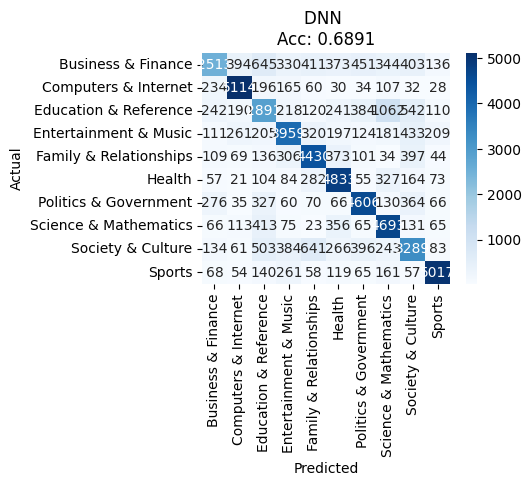

                        precision    recall  f1-score   support

    Business & Finance       0.66      0.42      0.51      6000
  Computers & Internet       0.81      0.85      0.83      6000
 Education & Reference       0.52      0.48      0.50      6000
 Entertainment & Music       0.68      0.66      0.67      6000
Family & Relationships       0.69      0.74      0.71      5999
                Health       0.71      0.81      0.75      6000
 Politics & Government       0.73      0.77      0.75      6000
 Science & Mathematics       0.64      0.78      0.71      6000
     Society & Culture       0.57      0.55      0.56      6000
                Sports       0.86      0.84      0.85      6000

              accuracy                           0.69     59999
             macro avg       0.69      0.69      0.68     59999
          weighted avg       0.69      0.69      0.68     59999



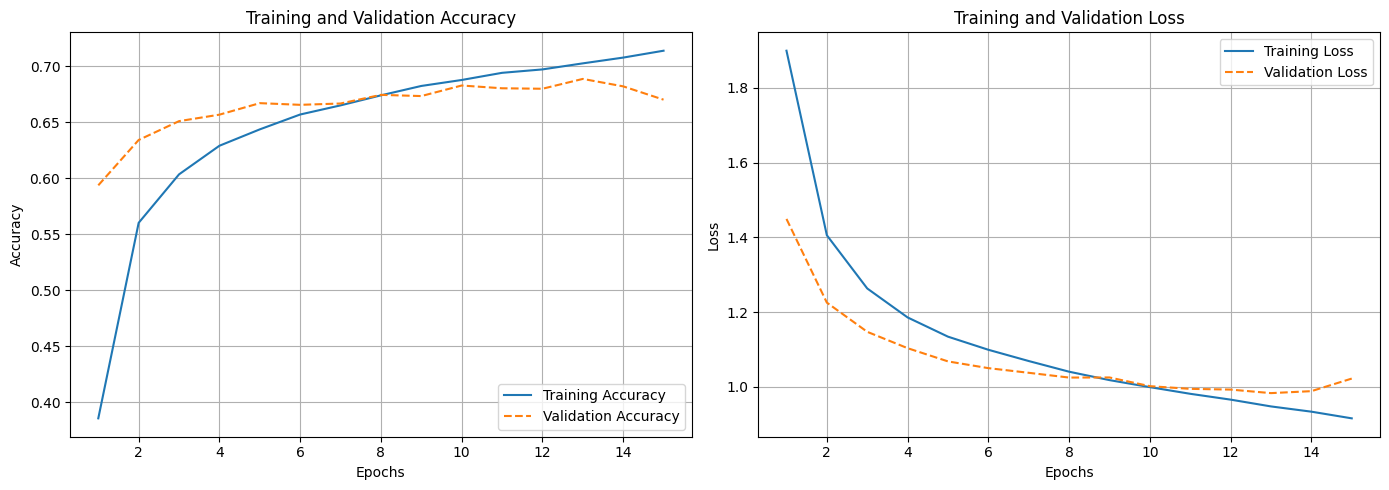

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import numpy as np
preds = model_dnn_1.predict(X_test_seq)
dnn_pred = np.argmax(preds, axis=1)

cm = confusion_matrix(y_test, dnn_pred)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=le.classes_, yticklabels=le.classes_)
name="DNN "
plt.title(f"{name}\nAcc: {acc_1:.4f}")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


classificationn_report = classification_report(y_test, dnn_pred, target_names=le.classes_)
print(classificationn_report)
import matplotlib.pyplot as plt

def plot_training_history(history):
    # Extract values from the history object
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    # Set up the figure
    plt.figure(figsize=(14, 5))

    # 1. Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linestyle='--')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    # 2. Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss', linestyle='--')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Run the plotting function
plot_training_history(history_1)

In [ ]:
#hp tuning 3
tf.keras.backend.clear_session()
from tensorflow.keras.layers import GlobalMaxPooling1D, BatchNormalization, Activation

print("\n--- Running Exp 3 (Option 2): Max Pooling + Batch Norm ---")

# HP Changes: Max Pooling, Batch Norm, Wider Layer
HP_opt2 = {
    'epochs': 20,
    'batch_size': 64,
    'dense_units': 512,      # Much wider layer
    'dropout_rate': 0.5      # Higher dropout because layer is wider
}

model_dnn_2 = Sequential([
    Embedding(vocab_size, 100, weights=[matrix_skip], input_length=200, trainable=False),

    # CHANGE 1: Max Pooling detects the presence of specific important words better than Average
    GlobalMaxPooling1D(),

    # CHANGE 2: BatchNormalization helps the model learn faster and prevents getting stuck
    Dense(HP_opt2['dense_units']), # No activation here, do it after BatchNorm
    BatchNormalization(),
    Activation('relu'),
    Dropout(HP_opt2['dropout_rate']),

    Dense(len(le.classes_), activation='softmax')
])

model_dnn_2.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history_2 = model_dnn_2.fit(
    X_train_seq, y_train,
    epochs=HP_opt2['epochs'],
    batch_size=HP_opt2['batch_size'],
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)
model_dnn_2.summary()
acc_2= model_dnn_2.evaluate(X_test_seq, y_test, verbose=0)[1]
experiment_results['3. Skip-gram + DNN'] = acc_2
print(f"✅ Accuracy: {acc_2:.4f}")


--- Running Exp 3 (Option 2): Max Pooling + Batch Norm ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/20
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.5131 - loss: 1.5235 - val_accuracy: 0.5531 - val_loss: 1.3615
Epoch 2/20
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5917 - loss: 1.2506 - val_accuracy: 0.6036 - val_loss: 1.2203
Epoch 3/20
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6035 - loss: 1.2165 - val_accuracy: 0.5964 - val_loss: 1.2478
Epoch 4/20
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6111 - loss: 1.2034 - val_accuracy: 0.5472 - val_loss: 1.3566
Epoch 5/20
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6148 - loss: 1.1910 - val_accuracy: 0.5978 - val_loss: 1.2264


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 100)       │    28,394,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 100)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │        51,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,568,724 (108.98 MB)

 Trainable params: 57,866 (226.04 KB)

 Non-trainable params: 28,395,124 (108.32 MB)

 Optimizer params: 115,734 (452.09 KB)

✅ Accuracy: 0.6013


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


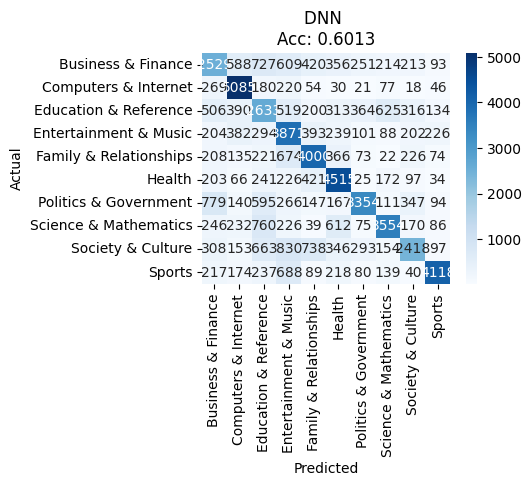

                        precision    recall  f1-score   support

    Business & Finance       0.46      0.42      0.44      6000
  Computers & Internet       0.69      0.85      0.76      6000
 Education & Reference       0.40      0.44      0.42      6000
 Entertainment & Music       0.48      0.65      0.55      6000
Family & Relationships       0.62      0.67      0.64      5999
                Health       0.63      0.75      0.69      6000
 Politics & Government       0.72      0.56      0.63      6000
 Science & Mathematics       0.69      0.59      0.64      6000
     Society & Culture       0.60      0.40      0.48      6000
                Sports       0.82      0.69      0.75      6000

              accuracy                           0.60     59999
             macro avg       0.61      0.60      0.60     59999
          weighted avg       0.61      0.60      0.60     59999



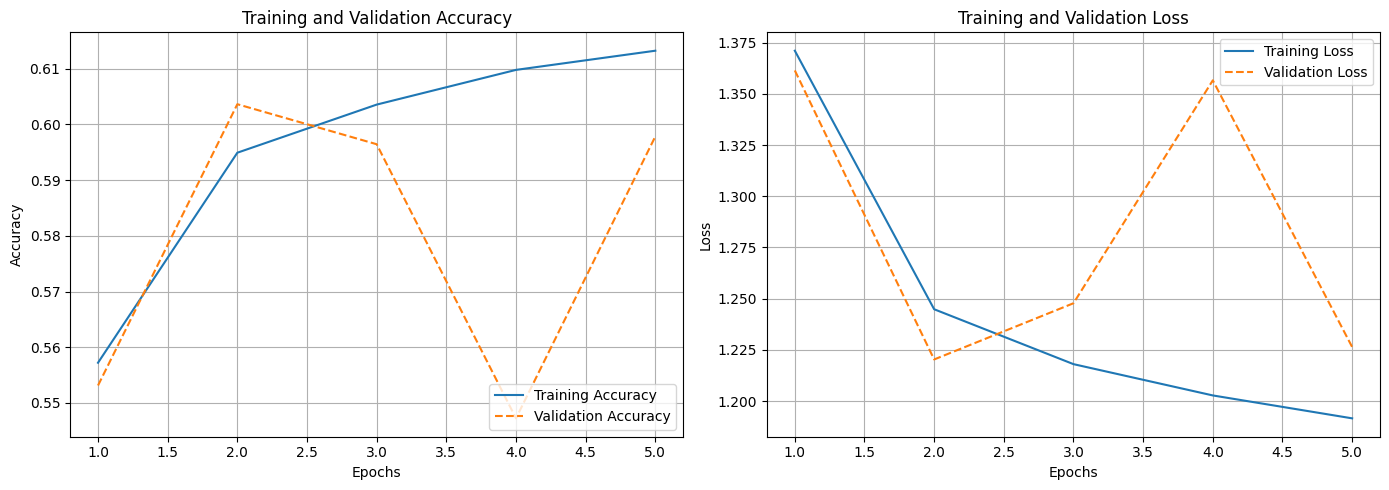

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import numpy as np
preds = model_dnn_2.predict(X_test_seq)
dnn_pred = np.argmax(preds, axis=1)

cm = confusion_matrix(y_test, dnn_pred)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=le.classes_, yticklabels=le.classes_)
name="DNN "
plt.title(f"{name}\nAcc: {acc_2:.4f}")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


classificationn_report = classification_report(y_test, dnn_pred, target_names=le.classes_)
print(classificationn_report)
import matplotlib.pyplot as plt

def plot_training_history(history):
    # Extract values from the history object
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    # Set up the figure
    plt.figure(figsize=(14, 5))

    # 1. Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linestyle='--')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    # 2. Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss', linestyle='--')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Run the plotting function
plot_training_history(history_2)

In [ ]:
accc=[acc,acc_1,acc_2]
accc.sort()
prediction["DNN"]=accc[-1]
print(accc[-1])
prediction

0.6890948414802551


{'logisticRegression': 0.6747112451874198,
 'DNN (TF-IDF)': 0.6709612011909485,
 'DNN': 0.6890948414802551}

In [ ]:
# tf.keras.backend.clear_session()


Simple RNN

In [ ]:
#hp tuning 1
tf.keras.backend.clear_session()
print("\n--- Running Exp 4: Skip-gram + SimpleRNN ---")
if 'experiment_results' not in locals():
    experiment_results = {}

# Hyperparameters (You can tune these per model if running separately!)
HP = {
    'epochs': 10,
    'batch_size': 64,
    'dense_units': 128,
    'rnn_units': 64,
    'dropout_rate': 0.3,
    'patience': 3
}

from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=HP['patience'], restore_best_weights=True)
model_rnn = Sequential([
    Embedding(vocab_size, 100, weights=[matrix_skip], input_length=200, trainable=False),
    SimpleRNN(HP['rnn_units'], dropout=HP['dropout_rate']),
    Dense(len(le.classes_), activation='softmax')
])

model_rnn.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history_rnn = model_rnn.fit(
    X_train_seq, y_train,
    epochs=HP['epochs'], batch_size=HP['batch_size'],
    validation_split=0.1, callbacks=[early_stop], verbose=1
)
model_rnn.summary()
acc = model_rnn.evaluate(X_test_seq, y_test, verbose=0)[1]
experiment_results['4. Skip-gram + SimpleRNN'] = acc
print(f"✅ Accuracy: {acc:.4f}")


--- Running Exp 4: Skip-gram + SimpleRNN ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 26s 18ms/step - accuracy: 0.3350 - loss: 1.9137 - val_accuracy: 0.3220 - val_loss: 2.2016
Epoch 2/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.3715 - loss: 1.8437 - val_accuracy: 0.5376 - val_loss: 1.4210
Epoch 3/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.4442 - loss: 1.6614 - val_accuracy: 0.4372 - val_loss: 1.6669
Epoch 4/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.3834 - loss: 1.8166 - val_accuracy: 0.4806 - val_loss: 1.5485
Epoch 5/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.4178 - loss: 1.7229 - val_accuracy: 0.4515 - val_loss: 1.6235


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 100)       │    28,394,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        10,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,427,732 (108.44 MB)

 Trainable params: 11,210 (43.79 KB)

 Non-trainable params: 28,394,100 (108.31 MB)

 Optimizer params: 22,422 (87.59 KB)

✅ Accuracy: 0.5277


In [ ]:
prediction["RNN"]=acc

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step


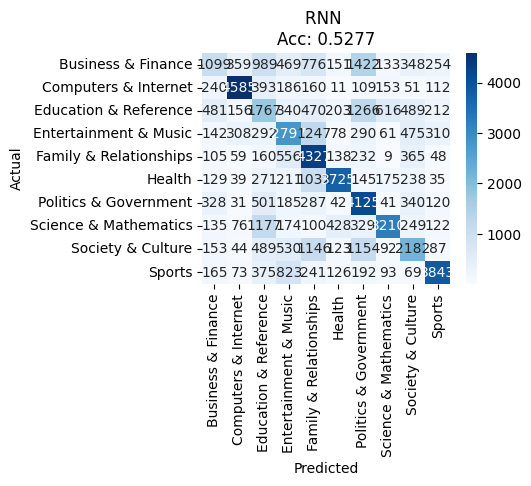

                        precision    recall  f1-score   support

    Business & Finance       0.37      0.18      0.24      6000
  Computers & Internet       0.80      0.76      0.78      6000
 Education & Reference       0.28      0.29      0.28      6000
 Entertainment & Music       0.45      0.47      0.46      6000
Family & Relationships       0.44      0.72      0.55      5999
                Health       0.74      0.62      0.68      6000
 Politics & Government       0.45      0.69      0.54      6000
 Science & Mathematics       0.70      0.54      0.61      6000
     Society & Culture       0.45      0.36      0.40      6000
                Sports       0.75      0.64      0.69      6000

              accuracy                           0.53     59999
             macro avg       0.54      0.53      0.52     59999
          weighted avg       0.54      0.53      0.52     59999



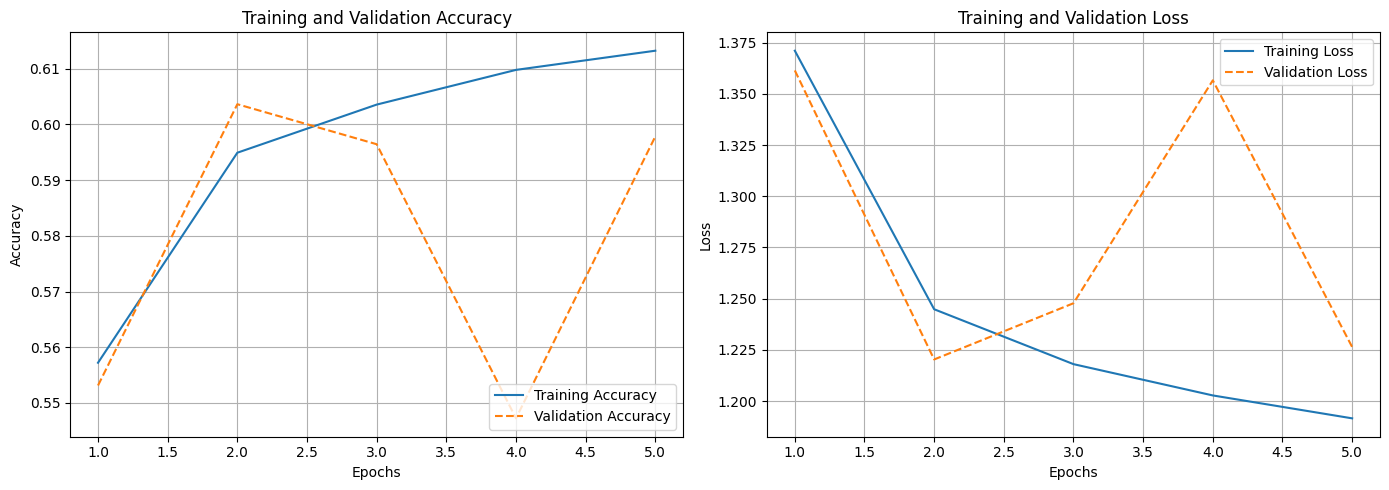

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import numpy as np
preds = model_rnn.predict(X_test_seq)
dnn_pred = np.argmax(preds, axis=1)

cm = confusion_matrix(y_test, dnn_pred)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=le.classes_, yticklabels=le.classes_)
name="RNN "
plt.title(f"{name}\nAcc: {acc:.4f}")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


classificationn_report = classification_report(y_test, dnn_pred, target_names=le.classes_)
print(classificationn_report)
import matplotlib.pyplot as plt

def plot_training_history(history):
    # Extract values from the history object
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    # Set up the figure
    plt.figure(figsize=(14, 5))

    # 1. Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linestyle='--')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    # 2. Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss', linestyle='--')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Run the plotting function
plot_training_history(history_2)

In [ ]:
#Skip+ Simple RNN tune 2
# Reset results dictionary if you are starting fresh
if 'experiment_results' not in locals():
    experiment_results = {}

# Hyperparameters (You can tune these per model if running separately!)
HP = {
    'epochs': 16,
    'batch_size': 32,
    'dense_units': 64,
    'rnn_units': 128,
    'dropout_rate': 0.4,
    'patience': 3
}

from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=HP['patience'], restore_best_weights=True)

print("\n--- Running Exp 4: Skip-gram + SimpleRNN ---")

model_rnn_1 = Sequential([
    Embedding(vocab_size, 100, weights=[matrix_skip], input_length=200, trainable=False),
    SimpleRNN(HP['rnn_units'], dropout=HP['dropout_rate']),
    Dense(len(le.classes_), activation='softmax')
])

model_rnn_1.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history_rnn= model_rnn_1.fit(
    X_train_seq, y_train,
    epochs=HP['epochs'], batch_size=HP['batch_size'],
    validation_split=0.1, callbacks=[early_stop], verbose=1
)
model_rnn_1.summary()

acc_1 = model_rnn_1.evaluate(X_test_seq, y_test, verbose=0)[1]
experiment_results['4. Skip-gram + SimpleRNN'] = acc_1
print(f"✅ Accuracy: {acc_1:.4f}")


--- Running Exp 4: Skip-gram + SimpleRNN ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/16
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 47s 17ms/step - accuracy: 0.3357 - loss: 1.9187 - val_accuracy: 0.2622 - val_loss: 2.1050
Epoch 2/16
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - accuracy: 0.3019 - loss: 1.9933 - val_accuracy: 0.3893 - val_loss: 1.7916
Epoch 3/16
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - accuracy: 0.3481 - loss: 1.8908 - val_accuracy: 0.4621 - val_loss: 1.6187
Epoch 4/16
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 40s 15ms/step - accuracy: 0.3622 - loss: 1.8658 - val_accuracy: 0.4290 - val_loss: 1.6752
Epoch 5/16
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - accuracy: 0.3341 - loss: 1.9320 - val_accuracy: 0.4735 - val_loss: 1.5895
Epoch 6/16
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 40s 15ms/step - accuracy: 0.3812 - loss: 1.8150 - val_accuracy: 0.4366 - val_loss: 1.6499
Epoch 7/16
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - accuracy: 0.3774 - loss: 1.8215 - val_accuracy: 0.3949 - val_loss: 1.7766
Epoch 8/16
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 40s 15ms/step - accuracy: 0.2716 -

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 100)       │    28,394,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 128)            │        29,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,485,908 (108.67 MB)

 Trainable params: 30,602 (119.54 KB)

 Non-trainable params: 28,394,100 (108.31 MB)

 Optimizer params: 61,206 (239.09 KB)

✅ Accuracy: 0.4646


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step


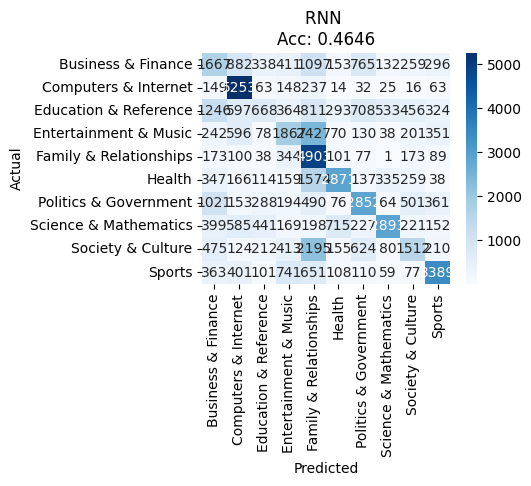

                        precision    recall  f1-score   support

    Business & Finance       0.27      0.28      0.28      6000
  Computers & Internet       0.59      0.88      0.71      6000
 Education & Reference       0.29      0.11      0.16      6000
 Entertainment & Music       0.39      0.31      0.35      6000
Family & Relationships       0.34      0.82      0.48      5999
                Health       0.63      0.48      0.54      6000
 Politics & Government       0.50      0.48      0.49      6000
 Science & Mathematics       0.70      0.48      0.57      6000
     Society & Culture       0.41      0.25      0.31      6000
                Sports       0.64      0.56      0.60      6000

              accuracy                           0.46     59999
             macro avg       0.48      0.46      0.45     59999
          weighted avg       0.48      0.46      0.45     59999



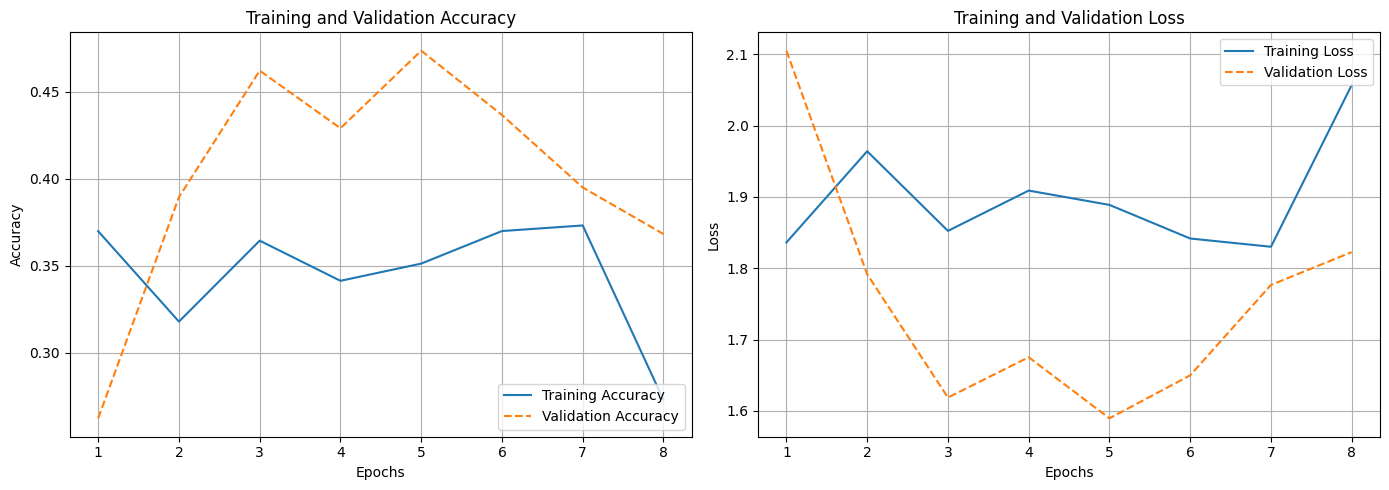

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import numpy as np
preds = model_rnn_1.predict(X_test_seq)
dnn_pred = np.argmax(preds, axis=1)

cm = confusion_matrix(y_test, dnn_pred)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=le.classes_, yticklabels=le.classes_)
name="RNN "
plt.title(f"{name}\nAcc: {acc_1:.4f}")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


classificationn_report = classification_report(y_test, dnn_pred, target_names=le.classes_)
print(classificationn_report)
import matplotlib.pyplot as plt

def plot_training_history(history):
    # Extract values from the history object
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    # Set up the figure
    plt.figure(figsize=(14, 5))

    # 1. Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linestyle='--')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    # 2. Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss', linestyle='--')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Run the plotting function
plot_training_history(history_rnn)

In [ ]:
#Skip+ Simple RNN tune 3
# Reset results dictionary if you are starting fresh
tf.keras.backend.clear_session()
if 'experiment_results' not in locals():
    experiment_results = {}

# Hyperparameters (You can tune these per model if running separately!)
HP = {
    'epochs': 18,
    'batch_size': 16,
    'dense_units': 128,
    'rnn_units': 128,
    'dropout_rate': 0.35,
    'patience': 3
}

from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=HP['patience'], restore_best_weights=True)

print("\n--- Running Exp 4: Skip-gram + SimpleRNN ---")

model_rnn_2= Sequential([
    Embedding(vocab_size, 100, weights=[matrix_skip], input_length=200, trainable=False),
    SimpleRNN(HP['rnn_units'], dropout=HP['dropout_rate']),
    Dense(len(le.classes_), activation='softmax')
])

model_rnn_2.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history_rnn_2 = model_rnn_2.fit(
    X_train_seq, y_train,
    epochs=HP['epochs'], batch_size=HP['batch_size'],
    validation_split=0.1, callbacks=[early_stop], verbose=1
)

acc_2= model_rnn_2.evaluate(X_test_seq, y_test, verbose=0)[1]
experiment_results['4. Skip-gram + SimpleRNN'] = acc_2
print(f"✅ Accuracy: {acc_2:.4f}")


--- Running Exp 4: Skip-gram + SimpleRNN ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/18
5250/5250 ━━━━━━━━━━━━━━━━━━━━ 79s 14ms/step - accuracy: 0.3331 - loss: 1.9287 - val_accuracy: 0.4485 - val_loss: 1.6418
Epoch 2/18
5250/5250 ━━━━━━━━━━━━━━━━━━━━ 77s 14ms/step - accuracy: 0.3619 - loss: 1.8595 - val_accuracy: 0.2034 - val_loss: 2.1687
Epoch 3/18
5250/5250 ━━━━━━━━━━━━━━━━━━━━ 74s 14ms/step - accuracy: 0.3136 - loss: 1.9602 - val_accuracy: 0.3410 - val_loss: 1.8987
Epoch 4/18
5250/5250 ━━━━━━━━━━━━━━━━━━━━ 82s 14ms/step - accuracy: 0.3192 - loss: 1.9553 - val_accuracy: 0.3219 - val_loss: 1.9483
✅ Accuracy: 0.4444


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step


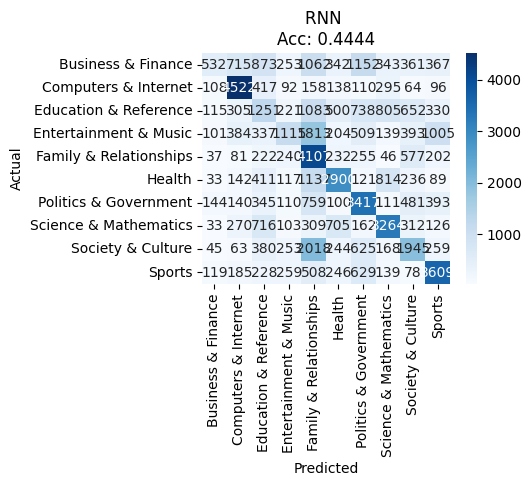

                        precision    recall  f1-score   support

    Business & Finance       0.42      0.09      0.15      6000
  Computers & Internet       0.66      0.75      0.71      6000
 Education & Reference       0.24      0.21      0.22      6000
 Entertainment & Music       0.40      0.19      0.25      6000
Family & Relationships       0.32      0.68      0.43      5999
                Health       0.52      0.48      0.50      6000
 Politics & Government       0.44      0.57      0.50      6000
 Science & Mathematics       0.53      0.54      0.54      6000
     Society & Culture       0.38      0.32      0.35      6000
                Sports       0.56      0.60      0.58      6000

              accuracy                           0.44     59999
             macro avg       0.45      0.44      0.42     59999
          weighted avg       0.45      0.44      0.42     59999



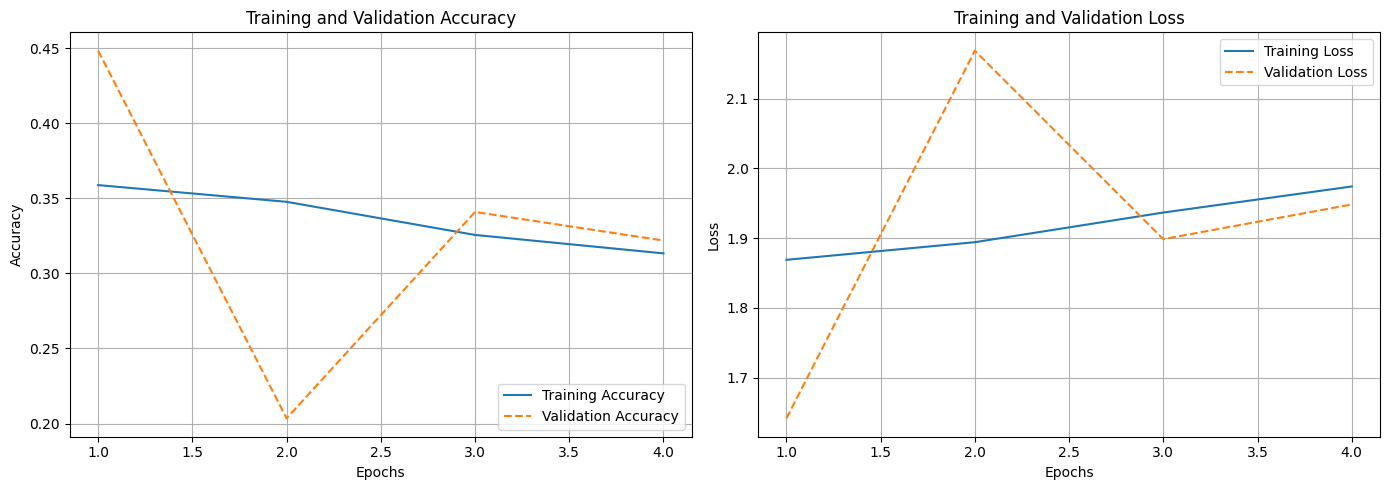

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import numpy as np
preds = model_rnn_2.predict(X_test_seq)
dnn_pred = np.argmax(preds, axis=1)

cm = confusion_matrix(y_test, dnn_pred)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=le.classes_, yticklabels=le.classes_)
name="RNN "
plt.title(f"{name}\nAcc: {acc_2:.4f}")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


classificationn_report = classification_report(y_test, dnn_pred, target_names=le.classes_)
print(classificationn_report)
import matplotlib.pyplot as plt

def plot_training_history(history):
    # Extract values from the history object
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    # Set up the figure
    plt.figure(figsize=(14, 5))

    # 1. Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linestyle='--')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    # 2. Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss', linestyle='--')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Run the plotting function
plot_training_history(history_rnn_2)

In [ ]:
accc=[acc,acc_1]
accc.sort()
prediction["RNN"]=accc[-1]

prediction

{'logisticRegression': 0.6747112451874198,
 'DNN (TF-IDF)': 0.6709612011909485,
 'DNN': 0.6890948414802551,
 'RNN': 0.527675449848175}

GRU

In [ ]:
#hp tuning 1
tf.keras.backend.clear_session()
print("\n--- Running Exp 5: Skip-gram + GRU ---")
HP_gru= {
    'epochs': 14,
    'batch_size': 32,
    'dense_units': 128,
    'rnn_units': 64,
    'dropout_rate': 0.25,
    'patience': 2
}
model_gru = Sequential([
    Embedding(vocab_size, 100, weights=[matrix_skip], input_length=200, trainable=False),
    SpatialDropout1D(HP_gru['dropout_rate']),
    GRU(HP_gru['rnn_units'], dropout=HP_gru['dropout_rate']),
    Dense(len(le.classes_), activation='softmax')
])

model_gru.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history_gru = model_gru.fit(
    X_train_seq, y_train,
    epochs=HP_gru['epochs'], batch_size=HP_gru['batch_size'],
    validation_split=0.1, callbacks=[early_stop], verbose=1
)
model_gru.summary()
acc = model_gru.evaluate(X_test_seq, y_test, verbose=0)[1]
experiment_results['5. Skip-gram + GRU'] = acc
print(f"✅ Accuracy: {acc:.4f}")


--- Running Exp 5: Skip-gram + GRU ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/14
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - accuracy: 0.4809 - loss: 1.5202 - val_accuracy: 0.6743 - val_loss: 0.9998
Epoch 2/14
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step - accuracy: 0.6423 - loss: 1.1014 - val_accuracy: 0.6796 - val_loss: 0.9831
Epoch 3/14
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step - accuracy: 0.6574 - loss: 1.0566 - val_accuracy: 0.6890 - val_loss: 0.9578
Epoch 4/14
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step - accuracy: 0.6638 - loss: 1.0373 - val_accuracy: 0.6880 - val_loss: 0.9543
Epoch 5/14
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 41s 11ms/step - accuracy: 0.6695 - loss: 1.0152 - val_accuracy: 0.6930 - val_loss: 0.9485
Epoch 6/14
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 30s 11ms/step - accuracy: 0.6709 - loss: 1.0096 - val_accuracy: 0.6933 - val_loss: 0.9416
Epoch 7/14
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step - accuracy: 0.6726 - loss: 1.0024 - val_accuracy: 0.6897 - val_loss: 0.9465
Epoch 8/14
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step - accuracy: 0.6757 -

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 100)       │    28,394,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 200, 100)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        31,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,491,668 (108.69 MB)

 Trainable params: 32,522 (127.04 KB)

 Non-trainable params: 28,394,100 (108.31 MB)

 Optimizer params: 65,046 (254.09 KB)

✅ Accuracy: 0.7027


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step


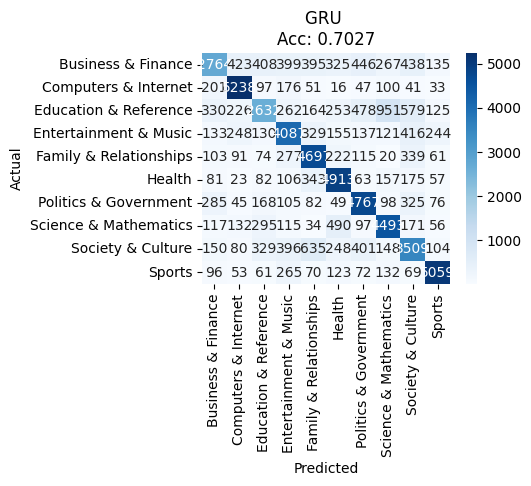

                        precision    recall  f1-score   support

    Business & Finance       0.65      0.46      0.54      6000
  Computers & Internet       0.80      0.87      0.83      6000
 Education & Reference       0.62      0.44      0.51      6000
 Entertainment & Music       0.66      0.68      0.67      6000
Family & Relationships       0.69      0.78      0.73      5999
                Health       0.72      0.82      0.77      6000
 Politics & Government       0.72      0.79      0.76      6000
 Science & Mathematics       0.69      0.75      0.72      6000
     Society & Culture       0.58      0.58      0.58      6000
                Sports       0.85      0.84      0.85      6000

              accuracy                           0.70     59999
             macro avg       0.70      0.70      0.70     59999
          weighted avg       0.70      0.70      0.70     59999



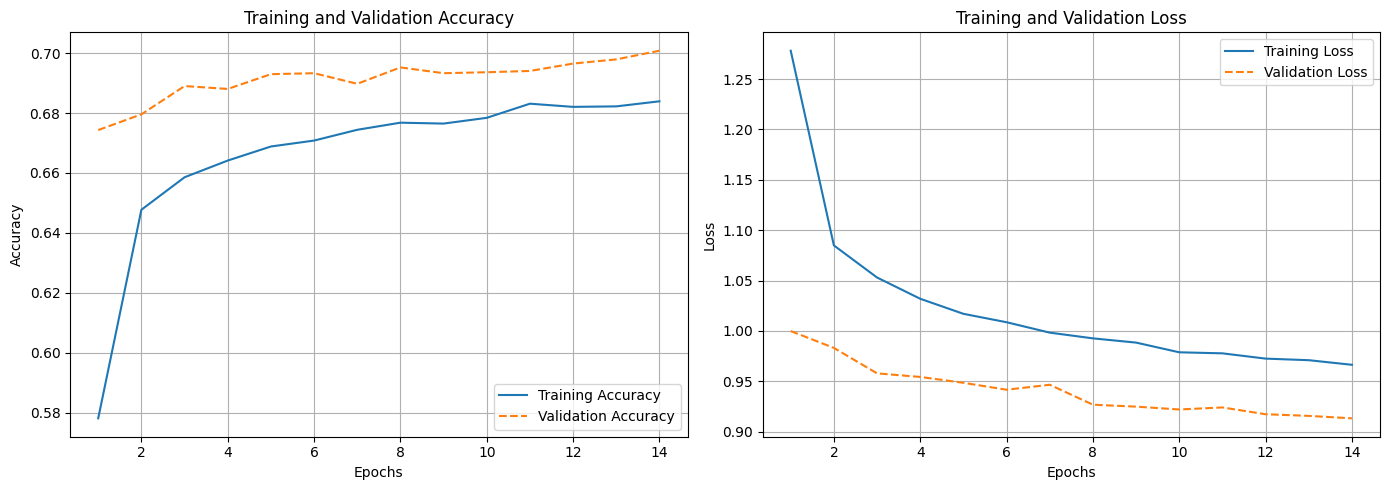

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import numpy as np
preds = model_gru.predict(X_test_seq)
dnn_pred = np.argmax(preds, axis=1)

cm = confusion_matrix(y_test, dnn_pred)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=le.classes_, yticklabels=le.classes_)
name="GRU "
plt.title(f"{name}\nAcc: {acc:.4f}")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


classificationn_report = classification_report(y_test, dnn_pred, target_names=le.classes_)
print(classificationn_report)
import matplotlib.pyplot as plt

def plot_training_history(history):
    # Extract values from the history object
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    # Set up the figure
    plt.figure(figsize=(14, 5))

    # 1. Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linestyle='--')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    # 2. Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss', linestyle='--')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Run the plotting function
plot_training_history(history_gru)

In [ ]:
#skip+ GRU tune 2
# Reset results dictionary if you are starting fresh
tf.keras.backend.clear_session()
if 'experiment_results' not in locals():
    experiment_results = {}

# Hyperparameters (You can tune these per model if running separately!)
HP = {
    'epochs': 16,
    'batch_size': 16,
    'dense_units': 64,
    'rnn_units': 128,
    'dropout_rate': 0.35,
    'patience': 4
}

from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=HP['patience'], restore_best_weights=True)


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN, GRU, LSTM, Bidirectional, Embedding, GlobalAveragePooling1D, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping


print("\n--- Running Exp 5: Skip-gram + GRU ---")

model_gru_1 = Sequential([
    Embedding(vocab_size, 100, weights=[matrix_skip], input_length=200, trainable=False),
    SpatialDropout1D(HP['dropout_rate']),
    GRU(HP['rnn_units'], dropout=HP['dropout_rate']),
    Dense(len(le.classes_), activation='softmax')
])

model_gru_1.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history_gru_1= model_gru_1.fit(
    X_train_seq, y_train,
    epochs=HP['epochs'], batch_size=HP['batch_size'],
    validation_split=0.1, callbacks=[early_stop], verbose=1
)
model_gru_1.summary()
acc_1= model_gru.evaluate(X_test_seq, y_test, verbose=0)[1]
experiment_results['5. Skip-gram + GRU'] = acc_1
print(f"✅ Accuracy: {acc_1:.4f}")




--- Running Exp 5: Skip-gram + GRU ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/16
5250/5250 ━━━━━━━━━━━━━━━━━━━━ 65s 12ms/step - accuracy: 0.5000 - loss: 1.4828 - val_accuracy: 0.6763 - val_loss: 0.9933
Epoch 2/16
5250/5250 ━━━━━━━━━━━━━━━━━━━━ 64s 12ms/step - accuracy: 0.6343 - loss: 1.1275 - val_accuracy: 0.6800 - val_loss: 0.9715
Epoch 3/16
5250/5250 ━━━━━━━━━━━━━━━━━━━━ 81s 12ms/step - accuracy: 0.6446 - loss: 1.0910 - val_accuracy: 0.6857 - val_loss: 0.9549
Epoch 4/16
5250/5250 ━━━━━━━━━━━━━━━━━━━━ 64s 12ms/step - accuracy: 0.6553 - loss: 1.0613 - val_accuracy: 0.6893 - val_loss: 0.9428
Epoch 5/16
5250/5250 ━━━━━━━━━━━━━━━━━━━━ 63s 12ms/step - accuracy: 0.6559 - loss: 1.0513 - val_accuracy: 0.6897 - val_loss: 0.9439
Epoch 6/16
5250/5250 ━━━━━━━━━━━━━━━━━━━━ 62s 12ms/step - accuracy: 0.6605 - loss: 1.0404 - val_accuracy: 0.6928 - val_loss: 0.9399
Epoch 7/16
5250/5250 ━━━━━━━━━━━━━━━━━━━━ 63s 12ms/step - accuracy: 0.6635 - loss: 1.0279 - val_accuracy: 0.6971 - val_loss: 0.9274
Epoch 8/16
5250/5250 ━━━━━━━━━━━━━━━━━━━━ 63s 12ms/step - accuracy: 0.6663 -

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 100)       │    28,394,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 200, 100)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 128)            │        88,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,662,932 (109.34 MB)

 Trainable params: 89,610 (350.04 KB)

 Non-trainable params: 28,394,100 (108.31 MB)

 Optimizer params: 179,222 (700.09 KB)

✅ Accuracy: 0.7027


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step


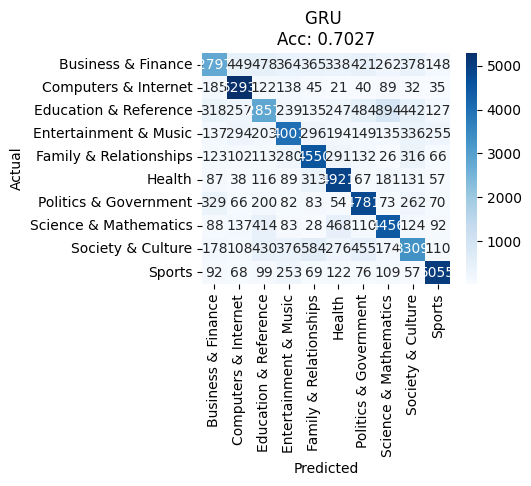

                        precision    recall  f1-score   support

    Business & Finance       0.65      0.47      0.54      6000
  Computers & Internet       0.78      0.88      0.83      6000
 Education & Reference       0.57      0.48      0.52      6000
 Entertainment & Music       0.68      0.67      0.67      6000
Family & Relationships       0.70      0.76      0.73      5999
                Health       0.71      0.82      0.76      6000
 Politics & Government       0.71      0.80      0.75      6000
 Science & Mathematics       0.70      0.74      0.72      6000
     Society & Culture       0.61      0.55      0.58      6000
                Sports       0.84      0.84      0.84      6000

              accuracy                           0.70     59999
             macro avg       0.69      0.70      0.69     59999
          weighted avg       0.69      0.70      0.69     59999



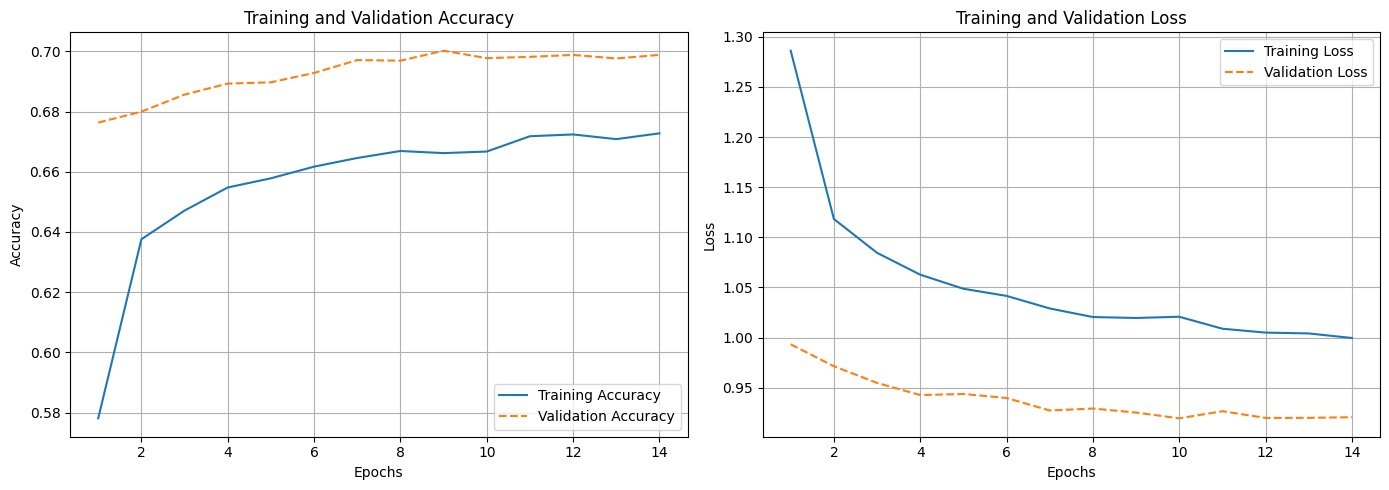

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import numpy as np
preds = model_gru_1.predict(X_test_seq)
dnn_pred = np.argmax(preds, axis=1)

cm = confusion_matrix(y_test, dnn_pred)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=le.classes_, yticklabels=le.classes_)
name="GRU "
plt.title(f"{name}\nAcc: {acc_1:.4f}")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


classificationn_report = classification_report(y_test, dnn_pred, target_names=le.classes_)
print(classificationn_report)
import matplotlib.pyplot as plt

def plot_training_history(history):
    # Extract values from the history object
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    # Set up the figure
    plt.figure(figsize=(14, 5))

    # 1. Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linestyle='--')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    # 2. Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss', linestyle='--')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Run the plotting function
plot_training_history(history_gru_1)

In [ ]:
accc=[acc,acc_1]
accc.sort()
prediction["GRU"]=accc[-1]
prediction

{'logisticRegression': 0.6747112451874198,
 'DNN (TF-IDF)': 0.6709612011909485,
 'DNN': 0.6890948414802551,
 'RNN': 0.527675449848175,
 'GRU': 0.7026616930961609}

LSTM

In [ ]:
#hp tuning 1
print("\n--- Running Exp 6: Skip-gram + LSTM ---")
tf.keras.backend.clear_session()
HP_lstm = {
    'epochs': 10,
    'batch_size': 64,
    'dense_units': 128,
    'rnn_units': 64,
    'dropout_rate': 0.3,
    'patience': 3
}

model_lstm = Sequential([
    Embedding(vocab_size, 100, weights=[matrix_skip], input_length=200, trainable=False),
    SpatialDropout1D(HP_lstm['dropout_rate']),
    LSTM(HP_lstm['rnn_units'], dropout=HP_lstm['dropout_rate']),
    Dense(len(le.classes_), activation='softmax')
])

model_lstm.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history_lstm = model_lstm.fit(
    X_train_seq, y_train,
    epochs=HP_lstm['epochs'], batch_size=HP_lstm['batch_size'],
    validation_split=0.1, callbacks=[early_stop], verbose=1
)
model_lstm.summary()
acc = model_lstm.evaluate(X_test_seq, y_test, verbose=0)[1]
experiment_results['6. Skip-gram + LSTM'] = acc
print(f"✅ Accuracy: {acc:.4f}")


--- Running Exp 6: Skip-gram + LSTM ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.4316 - loss: 1.6624 - val_accuracy: 0.6721 - val_loss: 1.0388
Epoch 2/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.6138 - loss: 1.1926 - val_accuracy: 0.6738 - val_loss: 1.0048
Epoch 3/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.6357 - loss: 1.1277 - val_accuracy: 0.6822 - val_loss: 0.9771
Epoch 4/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.6457 - loss: 1.0954 - val_accuracy: 0.6885 - val_loss: 0.9691
Epoch 5/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.6537 - loss: 1.0690 - val_accuracy: 0.6862 - val_loss: 0.9602
Epoch 6/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.6567 - loss: 1.0573 - val_accuracy: 0.6898 - val_loss: 0.9499
Epoch 7/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.6587 - loss: 1.0494 - val_accuracy: 0.6891 - val_loss: 0.9505
Epoch 8/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.6613 -

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 100)       │    28,394,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 200, 100)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,522,772 (108.81 MB)

 Trainable params: 42,890 (167.54 KB)

 Non-trainable params: 28,394,100 (108.31 MB)

 Optimizer params: 85,782 (335.09 KB)

✅ Accuracy: 0.6930


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step


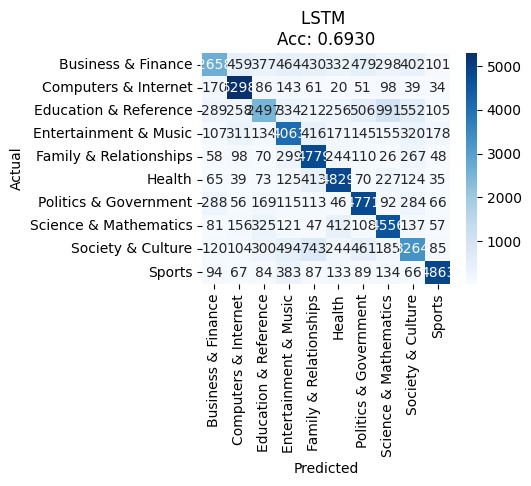

                        precision    recall  f1-score   support

    Business & Finance       0.68      0.44      0.54      6000
  Computers & Internet       0.77      0.88      0.82      6000
 Education & Reference       0.61      0.42      0.49      6000
 Entertainment & Music       0.62      0.68      0.65      6000
Family & Relationships       0.65      0.80      0.72      5999
                Health       0.72      0.80      0.76      6000
 Politics & Government       0.70      0.80      0.75      6000
 Science & Mathematics       0.67      0.76      0.71      6000
     Society & Culture       0.60      0.54      0.57      6000
                Sports       0.87      0.81      0.84      6000

              accuracy                           0.69     59999
             macro avg       0.69      0.69      0.69     59999
          weighted avg       0.69      0.69      0.69     59999



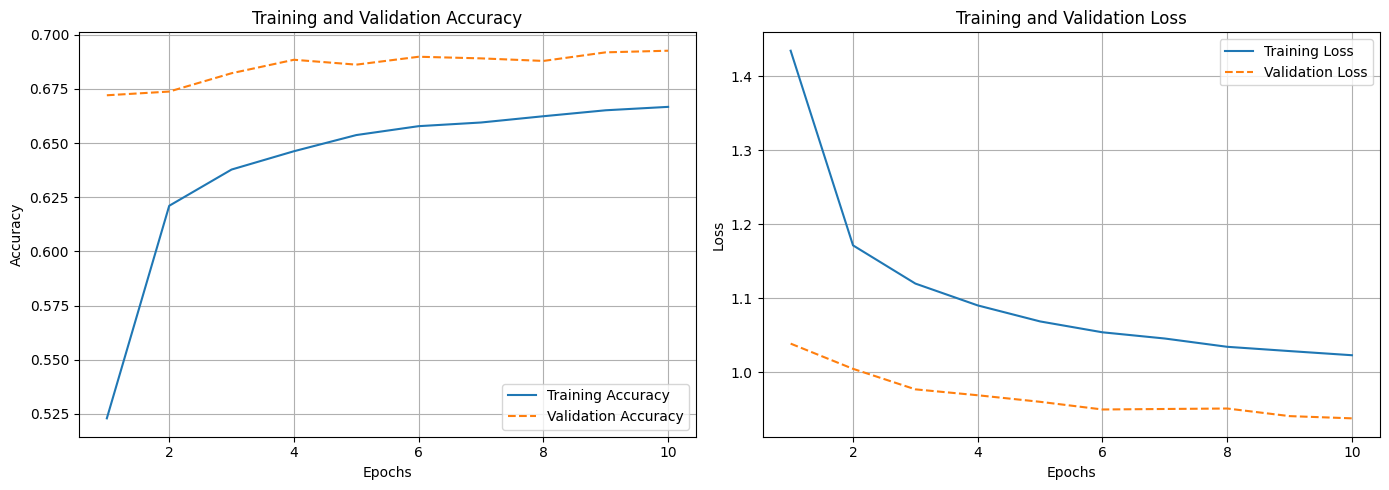

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import numpy as np
preds = model_lstm.predict(X_test_seq)
dnn_pred = np.argmax(preds, axis=1)

cm = confusion_matrix(y_test, dnn_pred)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=le.classes_, yticklabels=le.classes_)
name="LSTM "
plt.title(f"{name}\nAcc: {acc:.4f}")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


classificationn_report = classification_report(y_test, dnn_pred, target_names=le.classes_)
print(classificationn_report)
import matplotlib.pyplot as plt

def plot_training_history(history):
    # Extract values from the history object
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    # Set up the figure
    plt.figure(figsize=(14, 5))

    # 1. Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linestyle='--')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    # 2. Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss', linestyle='--')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Run the plotting function
plot_training_history(history_lstm)

In [ ]:
#skip+ LSTM tune 2
# Reset results dictionary if you are starting fresh
tf.keras.backend.clear_session()
if 'experiment_results' not in locals():
    experiment_results = {}


HP = {
    'epochs': 18,
    'batch_size': 16,
    'dense_units': 128,
    'rnn_units': 128,
    'dropout_rate': 0.35,
    'patience': 4
}

from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=HP['patience'], restore_best_weights=True)




from tensorflow.keras.layers import Dense, Dropout, SimpleRNN, GRU, LSTM, Bidirectional, Embedding, GlobalAveragePooling1D, SpatialDropout1D



print("\n--- Running Exp 6: Skip-gram + LSTM ---")

model_lstm_1= Sequential([
    Embedding(vocab_size, 100, weights=[matrix_skip], input_length=200, trainable=False),
    SpatialDropout1D(HP['dropout_rate']),
    LSTM(HP['rnn_units'], dropout=HP['dropout_rate']),
    Dense(len(le.classes_), activation='softmax')
])

model_lstm_1.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history_lstm_1= model_lstm_1.fit(
    X_train_seq, y_train,
    epochs=HP['epochs'], batch_size=HP['batch_size'],
    validation_split=0.1, callbacks=[early_stop], verbose=1
)

acc_1= model_lstm.evaluate(X_test_seq, y_test, verbose=0)[1]
experiment_results['6. Skip-gram + LSTM'] = acc_1
print(f"✅ Accuracy: {acc_1:.4f}")


--- Running Exp 6: Skip-gram + LSTM ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/18
5250/5250 ━━━━━━━━━━━━━━━━━━━━ 65s 12ms/step - accuracy: 0.4735 - loss: 1.5596 - val_accuracy: 0.6669 - val_loss: 1.0294
Epoch 2/18
5250/5250 ━━━━━━━━━━━━━━━━━━━━ 63s 12ms/step - accuracy: 0.6239 - loss: 1.1502 - val_accuracy: 0.6788 - val_loss: 0.9896
Epoch 3/18
5250/5250 ━━━━━━━━━━━━━━━━━━━━ 82s 12ms/step - accuracy: 0.6296 - loss: 1.1360 - val_accuracy: 0.6795 - val_loss: 0.9799
Epoch 4/18
5250/5250 ━━━━━━━━━━━━━━━━━━━━ 63s 12ms/step - accuracy: 0.6482 - loss: 1.0837 - val_accuracy: 0.6835 - val_loss: 0.9656
Epoch 5/18
5250/5250 ━━━━━━━━━━━━━━━━━━━━ 65s 12ms/step - accuracy: 0.6482 - loss: 1.0736 - val_accuracy: 0.6902 - val_loss: 0.9443
Epoch 6/18
5250/5250 ━━━━━━━━━━━━━━━━━━━━ 62s 12ms/step - accuracy: 0.6572 - loss: 1.0516 - val_accuracy: 0.6960 - val_loss: 0.9429
Epoch 7/18
5250/5250 ━━━━━━━━━━━━━━━━━━━━ 63s 12ms/step - accuracy: 0.6608 - loss: 1.0361 - val_accuracy: 0.6973 - val_loss: 0.9350
Epoch 8/18
5250/5250 ━━━━━━━━━━━━━━━━━━━━ 65s 12ms/step - accuracy: 0.6619 -

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step


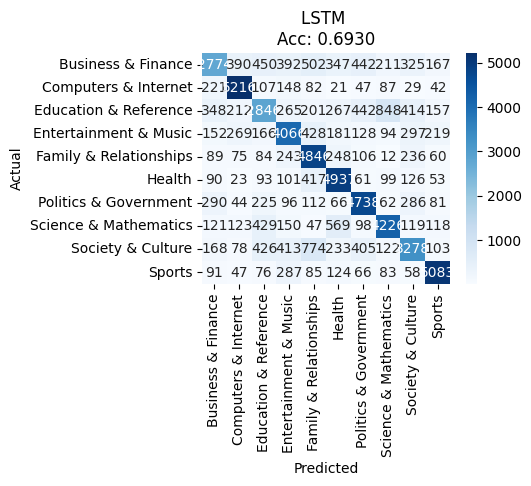

                        precision    recall  f1-score   support

    Business & Finance       0.64      0.46      0.54      6000
  Computers & Internet       0.81      0.87      0.84      6000
 Education & Reference       0.58      0.47      0.52      6000
 Entertainment & Music       0.66      0.68      0.67      6000
Family & Relationships       0.65      0.81      0.72      5999
                Health       0.71      0.82      0.76      6000
 Politics & Government       0.73      0.79      0.76      6000
 Science & Mathematics       0.72      0.70      0.71      6000
     Society & Culture       0.63      0.55      0.59      6000
                Sports       0.84      0.85      0.84      6000

              accuracy                           0.70     59999
             macro avg       0.70      0.70      0.69     59999
          weighted avg       0.70      0.70      0.69     59999



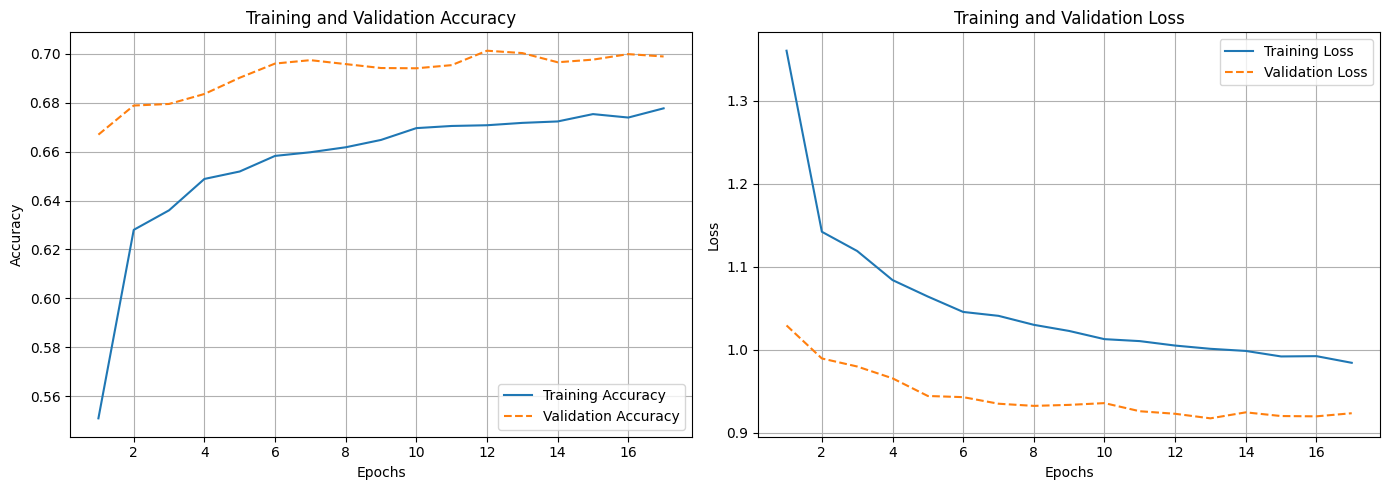

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import numpy as np
preds = model_lstm_1.predict(X_test_seq)
dnn_pred = np.argmax(preds, axis=1)

cm = confusion_matrix(y_test, dnn_pred)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=le.classes_, yticklabels=le.classes_)
name="LSTM "
plt.title(f"{name}\nAcc: {acc_1:.4f}")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


classificationn_report = classification_report(y_test, dnn_pred, target_names=le.classes_)
print(classificationn_report)
import matplotlib.pyplot as plt

def plot_training_history(history):
    # Extract values from the history object
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    # Set up the figure
    plt.figure(figsize=(14, 5))

    # 1. Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linestyle='--')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    # 2. Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss', linestyle='--')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Run the plotting function
plot_training_history(history_lstm_1)

In [ ]:
accc=[acc,acc_1]
accc.sort()
prediction["LSTM"]=accc[-1]
prediction

{'logisticRegression': 0.6747112451874198,
 'DNN (TF-IDF)': 0.6709612011909485,
 'DNN': 0.6890948414802551,
 'RNN': 0.527675449848175,
 'GRU': 0.7026616930961609,
 'LSTM': 0.6929782032966614}

Bi-Simple RNN

In [ ]:
#hp tuning 1
tf.keras.backend.clear_session()
HP1 = {
    'epochs': 15,
    'batch_size': 128,        # Increased batch size for stable updates
    'rnn_units': 128,         # Doubled neurons (64 -> 128)
    'dropout_rate': 0.3,
    'dense_units': 128,
    'patience': 4
}

# Define Early Stopping
early_stop_1 = EarlyStopping(monitor='val_loss', patience=HP1['patience'], restore_best_weights=True)

print("\n========== TUNING ATTEMPT 1: High Capacity ==========")


print("\n--- Running 1. Tuned Bi-SimpleRNN ---")
model_birnn_1 = Sequential([
    # trainable=True allows the model to fine-tune the Word2Vec weights
    Embedding(vocab_size, 100, weights=[matrix_skip], input_length=200, trainable=True),
    Bidirectional(SimpleRNN(HP1['rnn_units'], dropout=HP1['dropout_rate'])),
    Dense(HP1['dense_units'], activation='relu'), # Extra Dense Layer
    Dropout(0.3),
    Dense(len(le.classes_), activation='softmax')
])

model_birnn_1.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history_birnn=model_birnn_1.fit(X_train_seq, y_train,
                  epochs=HP1['epochs'], batch_size=HP1['batch_size'],
                  validation_split=0.1, callbacks=[early_stop_1], verbose=1)

# EVALUATE & PRINT
model_birnn_1.summary()
acc_birnn_1 = model_birnn_1.evaluate(X_test_seq, y_test, verbose=0)[1]
experiment_results['Tuned-1 Bi-SimpleRNN'] = acc_birnn_1
print(f"✅ Accuracy for Tuned Bi-SimpleRNN: {acc_birnn_1:.4f}")



========== TUNING ATTEMPT 1: High Capacity ==========

--- Running 1. Tuned Bi-SimpleRNN ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 37s 47ms/step - accuracy: 0.3465 - loss: 1.8768 - val_accuracy: 0.5954 - val_loss: 1.2975
Epoch 2/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 26s 40ms/step - accuracy: 0.5569 - loss: 1.4200 - val_accuracy: 0.5990 - val_loss: 1.2807
Epoch 3/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 26s 40ms/step - accuracy: 0.4749 - loss: 1.5965 - val_accuracy: 0.4546 - val_loss: 1.6106
Epoch 4/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 26s 40ms/step - accuracy: 0.4925 - loss: 1.5404 - val_accuracy: 0.5226 - val_loss: 1.4958
Epoch 5/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 26s 40ms/step - accuracy: 0.4003 - loss: 1.7556 - val_accuracy: 0.5610 - val_loss: 1.3653
Epoch 6/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 26s 40ms/step - accuracy: 0.5272 - loss: 1.4614 - val_accuracy: 0.5723 - val_loss: 1.3413


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 100)       │    28,394,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │        58,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,460,732 (326.01 MB)

 Trainable params: 28,486,910 (108.67 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 56,973,822 (217.34 MB)

✅ Accuracy for Tuned Bi-SimpleRNN: 0.5947


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step


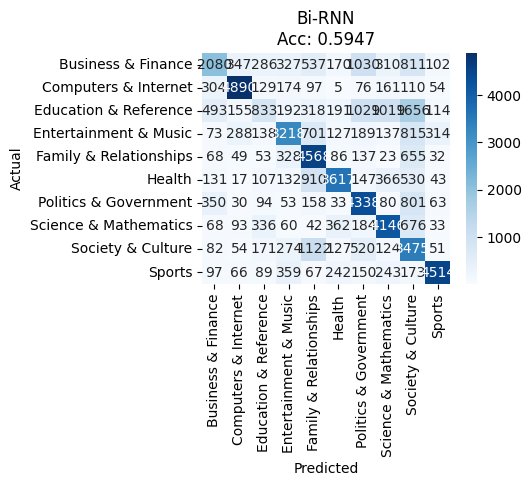

                        precision    recall  f1-score   support

    Business & Finance       0.56      0.35      0.43      6000
  Computers & Internet       0.82      0.81      0.82      6000
 Education & Reference       0.37      0.14      0.20      6000
 Entertainment & Music       0.63      0.54      0.58      6000
Family & Relationships       0.54      0.76      0.63      5999
                Health       0.73      0.60      0.66      6000
 Politics & Government       0.56      0.72      0.63      6000
 Science & Mathematics       0.63      0.69      0.66      6000
     Society & Culture       0.36      0.58      0.44      6000
                Sports       0.85      0.75      0.80      6000

              accuracy                           0.59     59999
             macro avg       0.60      0.59      0.58     59999
          weighted avg       0.60      0.59      0.58     59999



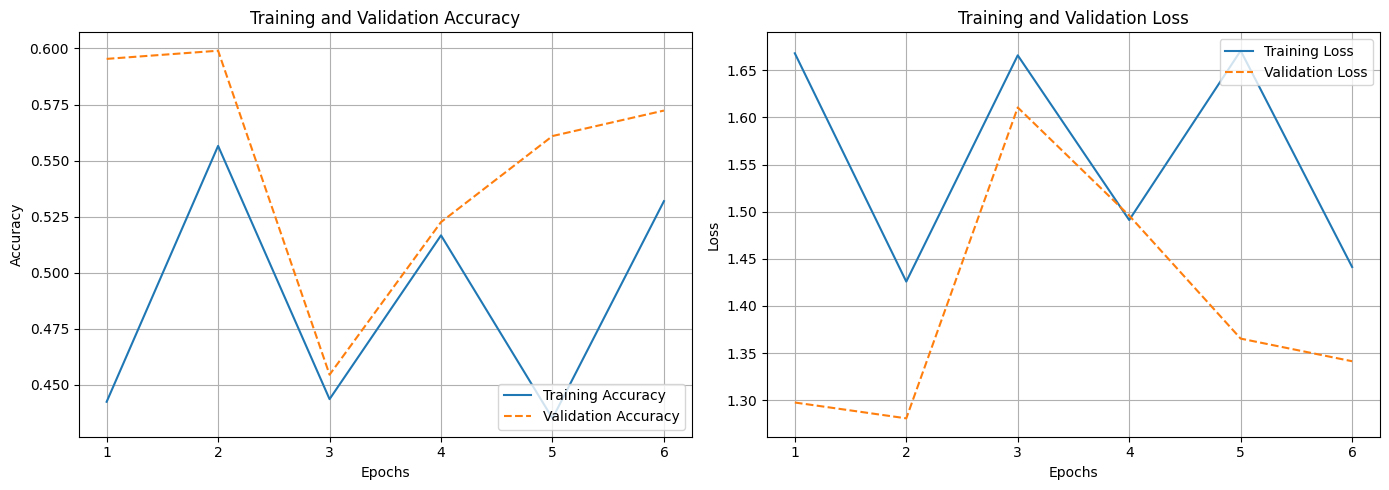

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import numpy as np
preds = model_birnn_1.predict(X_test_seq)
dnn_pred = np.argmax(preds, axis=1)

cm = confusion_matrix(y_test, dnn_pred)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=le.classes_, yticklabels=le.classes_)
name="Bi-RNN"
plt.title(f"{name}\nAcc: {acc_birnn_1:.4f}")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


classificationn_report = classification_report(y_test, dnn_pred, target_names=le.classes_)
print(classificationn_report)
import matplotlib.pyplot as plt

def plot_training_history(history):
    # Extract values from the history object
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    # Set up the figure
    plt.figure(figsize=(14, 5))

    # 1. Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linestyle='--')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    # 2. Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss', linestyle='--')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Run the plotting function
plot_training_history(history_birnn)

In [ ]:


#hp tuning 2


print("\n--- Running Exp 7: Speed-Optimized Bi-SimpleRNN ---")

HP_RNN = {
    'epochs': 12,
    'batch_size': 512,      # INCREASED: 64 -> 512 (Much faster training)
    'rnn_units': 128,
    'dropout_rate': 0.2,
    'lr': 0.01
}

early_stop_rnn = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model_birnn_opt = Sequential([
    Embedding(vocab_size, 100, weights=[matrix_skip], input_length=200, trainable=True),

    Bidirectional(SimpleRNN(HP_RNN['rnn_units'], dropout=HP_RNN['dropout_rate'], unroll=True)),

    Dense(128, activation='relu'),
    Dense(len(le.classes_), activation='softmax')
])

opt_rnn = Adam(learning_rate=HP_RNN['lr'], clipnorm=1.0)

model_birnn_opt.compile(loss='sparse_categorical_crossentropy', optimizer=opt_rnn, metrics=['accuracy'])

history_birnn_1= model_birnn_opt.fit(
    X_train_seq, y_train,
    epochs=HP_RNN['epochs'], batch_size=HP_RNN['batch_size'],
    validation_split=0.1, callbacks=[early_stop_rnn], verbose=1
)

acc_rnn = model_birnn_opt.evaluate(X_test_seq, y_test, verbose=0)[1]
print(f"✅ FINAL ACCURACY (Bi-SimpleRNN): {acc_rnn:.4f}")


--- Running Exp 7: Speed-Optimized Bi-SimpleRNN ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/12
165/165 ━━━━━━━━━━━━━━━━━━━━ 224s 919ms/step - accuracy: 0.1353 - loss: 2.4622 - val_accuracy: 0.3249 - val_loss: 1.8770
Epoch 2/12
165/165 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.3172 - loss: 1.9481 - val_accuracy: 0.3105 - val_loss: 1.9935
Epoch 3/12
165/165 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.3157 - loss: 1.9127 - val_accuracy: 0.3868 - val_loss: 1.8214
Epoch 4/12
165/165 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step - accuracy: 0.3983 - loss: 1.7426 - val_accuracy: 0.3812 - val_loss: 1.7848
Epoch 5/12
165/165 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step - accuracy: 0.4091 - loss: 1.7117 - val_accuracy: 0.4056 - val_loss: 1.7701
Epoch 6/12
165/165 ━━━━━━━━━━━━━━━━━━━━ 9s 57ms/step - accuracy: 0.4451 - loss: 1.6203 - val_accuracy: 0.4333 - val_loss: 1.6873
Epoch 7/12
165/165 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step - accuracy: 0.4465 - loss: 1.6217 - val_accuracy: 0.3951 - val_loss: 1.8136
Epoch 8/12
165/165 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step - accuracy: 0.4268 - loss: 1.6753 - va

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 15ms/step


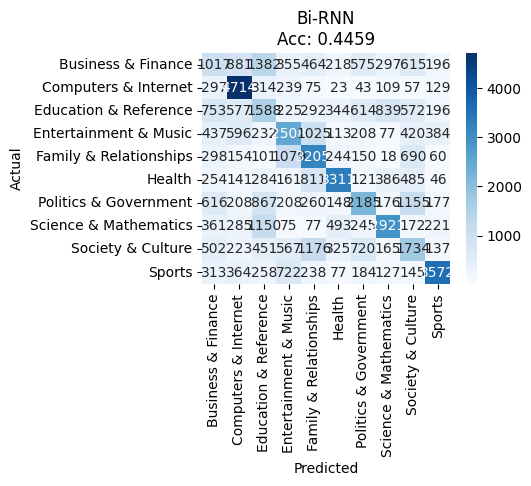

                        precision    recall  f1-score   support

    Business & Finance       0.21      0.17      0.19      6000
  Computers & Internet       0.58      0.79      0.67      6000
 Education & Reference       0.24      0.26      0.25      6000
 Entertainment & Music       0.41      0.42      0.41      6000
Family & Relationships       0.42      0.53      0.47      5999
                Health       0.63      0.55      0.59      6000
 Politics & Government       0.43      0.36      0.40      6000
 Science & Mathematics       0.57      0.49      0.53      6000
     Society & Culture       0.29      0.29      0.29      6000
                Sports       0.70      0.60      0.64      6000

              accuracy                           0.45     59999
             macro avg       0.45      0.45      0.44     59999
          weighted avg       0.45      0.45      0.44     59999



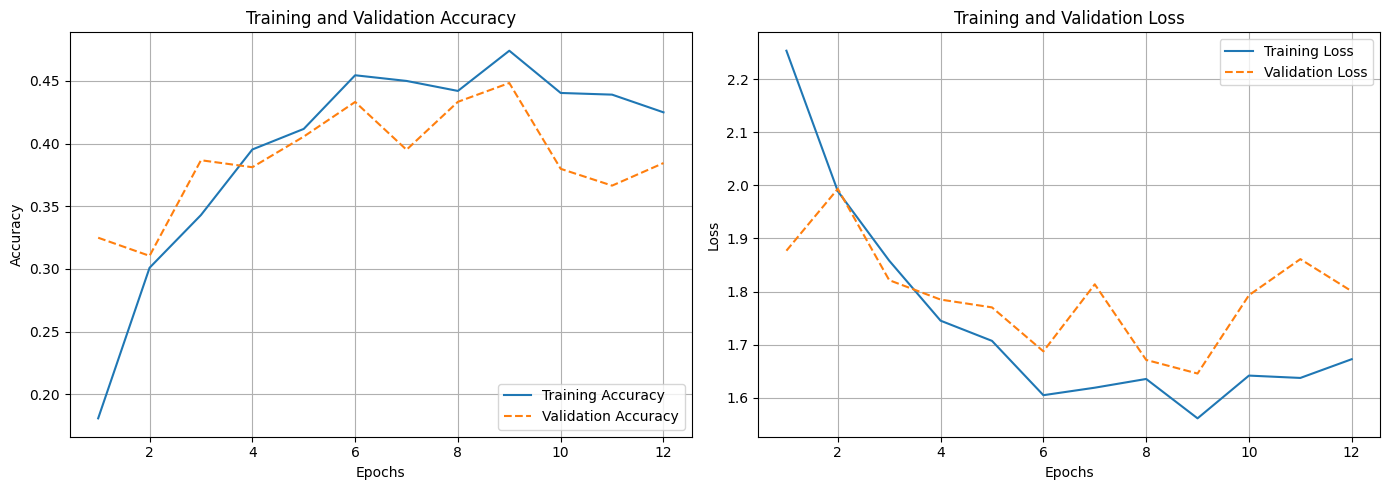

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import numpy as np
preds = model_birnn_opt.predict(X_test_seq)
dnn_pred = np.argmax(preds, axis=1)

cm = confusion_matrix(y_test, dnn_pred)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=le.classes_, yticklabels=le.classes_)
name="Bi-RNN"
plt.title(f"{name}\nAcc: {acc_rnn:.4f}")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


classificationn_report = classification_report(y_test, dnn_pred, target_names=le.classes_)
print(classificationn_report)
import matplotlib.pyplot as plt

def plot_training_history(history):
    # Extract values from the history object
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    # Set up the figure
    plt.figure(figsize=(14, 5))

    # 1. Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linestyle='--')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    # 2. Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss', linestyle='--')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Run the plotting function
plot_training_history(history_birnn_1)

In [ ]:
accc=[acc_birnn_1,acc_rnn]
accc.sort()
prediction["Bi-RNN"]=accc[-1]
prediction


{'logisticRegression': 0.6747112451874198,
 'DNN (TF-IDF)': 0.6709612011909485,
 'DNN': 0.6890948414802551,
 'RNN': 0.527675449848175,
 'GRU': 0.7026616930961609,
 'LSTM': 0.6929782032966614,
 'Bi-RNN': 0.5946599245071411}

Bi- GRU

In [ ]:
#hp tuning 1
print("\n--- Running 2. Tuned Bi-GRU ---")
tf.keras.backend.clear_session()
HP1 = {
    'epochs': 15,
    'batch_size': 128,        # Increased batch size for stable updates
    'rnn_units': 128,         # Doubled neurons (64 -> 128)
    'dropout_rate': 0.3,
    'dense_units': 128,
    'patience': 4
}

# Define Early Stopping
early_stop_1 = EarlyStopping(monitor='val_loss', patience=HP1['patience'], restore_best_weights=True)
model_bigru_1 = Sequential([
    Embedding(vocab_size, 100, weights=[matrix_skip], input_length=200, trainable=True),
    SpatialDropout1D(HP1['dropout_rate']),
    Bidirectional(GRU(HP1['rnn_units'], dropout=HP1['dropout_rate'])),
    Dense(HP1['dense_units'], activation='relu'),
    Dropout(0.3),
    Dense(len(le.classes_), activation='softmax')
])

model_bigru_1.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history_bigru=model_bigru_1.fit(X_train_seq, y_train,
                  epochs=HP1['epochs'], batch_size=HP1['batch_size'],
                  validation_split=0.1, callbacks=[early_stop_1], verbose=1)

# EVALUATE & PRINT
model_bigru_1.summary()
acc_bigru_1 = model_bigru_1.evaluate(X_test_seq, y_test, verbose=0)[1]
experiment_results['Tuned-1 Bi-GRU'] = acc_bigru_1
print(f"✅ Accuracy for Tuned Bi-GRU: {acc_bigru_1:.4f}")


--- Running 2. Tuned Bi-GRU ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 35s 47ms/step - accuracy: 0.4350 - loss: 1.6448 - val_accuracy: 0.6795 - val_loss: 0.9895
Epoch 2/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 30s 46ms/step - accuracy: 0.6686 - loss: 1.0430 - val_accuracy: 0.7032 - val_loss: 0.9224
Epoch 3/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 31s 47ms/step - accuracy: 0.6983 - loss: 0.9608 - val_accuracy: 0.7079 - val_loss: 0.9041
Epoch 4/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 30s 46ms/step - accuracy: 0.7192 - loss: 0.8904 - val_accuracy: 0.7088 - val_loss: 0.9054
Epoch 5/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 30s 46ms/step - accuracy: 0.7293 - loss: 0.8570 - val_accuracy: 0.7116 - val_loss: 0.9038
Epoch 6/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 41s 46ms/step - accuracy: 0.7396 - loss: 0.8167 - val_accuracy: 0.7109 - val_loss: 0.9184
Epoch 7/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 31s 46ms/step - accuracy: 0.7505 - loss: 0.7772 - val_accuracy: 0.7076 - val_loss: 0.9376
Epoch 8/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 30s 45ms/step - accuracy: 0.7622 - loss: 0.7421 - 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 100)       │    28,394,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 200, 100)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       176,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,814,780 (327.36 MB)

 Trainable params: 28,604,926 (109.12 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 57,209,854 (218.24 MB)

✅ Accuracy for Tuned Bi-GRU: 0.7117


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step


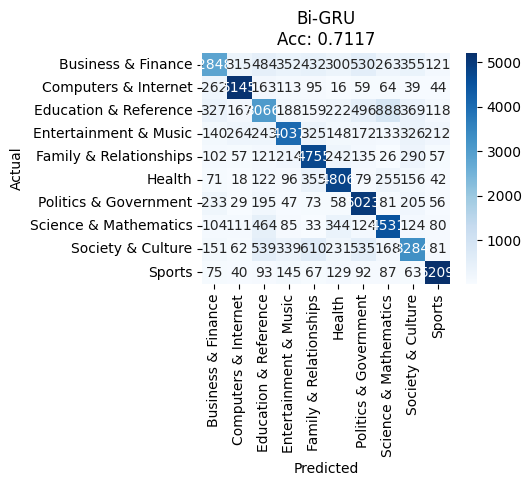

                        precision    recall  f1-score   support

    Business & Finance       0.66      0.47      0.55      6000
  Computers & Internet       0.83      0.86      0.84      6000
 Education & Reference       0.56      0.51      0.53      6000
 Entertainment & Music       0.72      0.67      0.70      6000
Family & Relationships       0.69      0.79      0.74      5999
                Health       0.74      0.80      0.77      6000
 Politics & Government       0.69      0.84      0.76      6000
 Science & Mathematics       0.70      0.76      0.73      6000
     Society & Culture       0.63      0.55      0.59      6000
                Sports       0.87      0.87      0.87      6000

              accuracy                           0.71     59999
             macro avg       0.71      0.71      0.71     59999
          weighted avg       0.71      0.71      0.71     59999



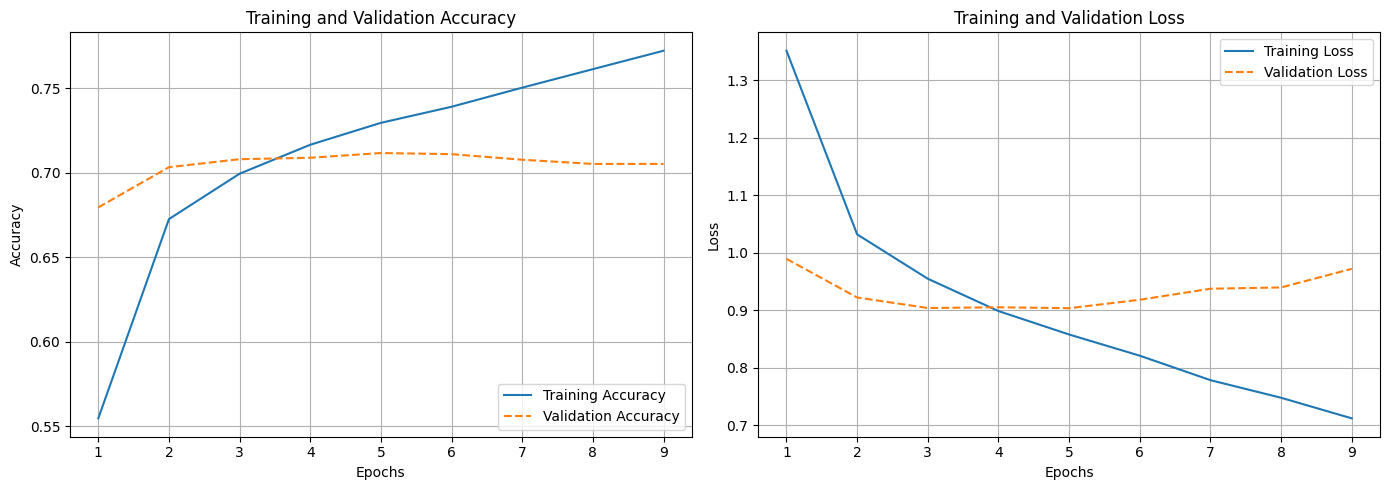

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import numpy as np
preds = model_bigru_1.predict(X_test_seq)
dnn_pred = np.argmax(preds, axis=1)

cm = confusion_matrix(y_test, dnn_pred)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=le.classes_, yticklabels=le.classes_)
name="Bi-GRU"
plt.title(f"{name}\nAcc: {acc_bigru_1:.4f}")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


classificationn_report = classification_report(y_test, dnn_pred, target_names=le.classes_)
print(classificationn_report)
import matplotlib.pyplot as plt

def plot_training_history(history):
    # Extract values from the history object
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    # Set up the figure
    plt.figure(figsize=(14, 5))

    # 1. Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linestyle='--')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    # 2. Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss', linestyle='--')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Run the plotting function
plot_training_history(history_bigru)

In [ ]:
#hp tuning 2
print("\n--- Running Exp 8: Speed-Optimized Bi-GRU ---")
tf.keras.backend.clear_session()
HP_GRU = {
    'epochs': 15,
    'batch_size': 512,      # INCREASED: 128 -> 512 (Huge Speedup)
    'rnn_units': 128,
    'lr': 0.001
}

early_stop_gru = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model_bigru_opt = Sequential([
    Embedding(vocab_size, 100, weights=[matrix_skip], input_length=200, trainable=True),

    SpatialDropout1D(0.4),


    Bidirectional(GRU(HP_GRU['rnn_units'])),

    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(len(le.classes_), activation='softmax')
])

model_bigru_opt.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(learning_rate=HP_GRU['lr']), metrics=['accuracy'])

history_bigru_1= model_bigru_opt.fit(
    X_train_seq, y_train,
    epochs=HP_GRU['epochs'], batch_size=HP_GRU['batch_size'],
    validation_split=0.1, callbacks=[early_stop_gru], verbose=1
)

acc_gru= model_bigru_opt.evaluate(X_test_seq, y_test, verbose=0)[1]
experiment_results['8. Optimized Bi-GRU'] = acc_gru
print(f"✅ FINAL ACCURACY (Bi-GRU): {acc_gru:.4f}")


--- Running Exp 8: Speed-Optimized Bi-GRU ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/15
165/165 ━━━━━━━━━━━━━━━━━━━━ 19s 94ms/step - accuracy: 0.3476 - loss: 1.8511 - val_accuracy: 0.6741 - val_loss: 1.0226
Epoch 2/15
165/165 ━━━━━━━━━━━━━━━━━━━━ 15s 93ms/step - accuracy: 0.6476 - loss: 1.1008 - val_accuracy: 0.6935 - val_loss: 0.9501
Epoch 3/15
165/165 ━━━━━━━━━━━━━━━━━━━━ 15s 92ms/step - accuracy: 0.6827 - loss: 1.0031 - val_accuracy: 0.7057 - val_loss: 0.9257
Epoch 4/15
165/165 ━━━━━━━━━━━━━━━━━━━━ 15s 91ms/step - accuracy: 0.7047 - loss: 0.9374 - val_accuracy: 0.7038 - val_loss: 0.9162
Epoch 5/15
165/165 ━━━━━━━━━━━━━━━━━━━━ 15s 92ms/step - accuracy: 0.7149 - loss: 0.9035 - val_accuracy: 0.7075 - val_loss: 0.9100
Epoch 6/15
165/165 ━━━━━━━━━━━━━━━━━━━━ 15s 92ms/step - accuracy: 0.7264 - loss: 0.8662 - val_accuracy: 0.7067 - val_loss: 0.9053
Epoch 7/15
165/165 ━━━━━━━━━━━━━━━━━━━━ 15s 92ms/step - accuracy: 0.7364 - loss: 0.8284 - val_accuracy: 0.7105 - val_loss: 0.9008
Epoch 8/15
165/165 ━━━━━━━━━━━━━━━━━━━━ 20s 91ms/step - accuracy: 0.7461 - loss: 0.8057 - 

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step


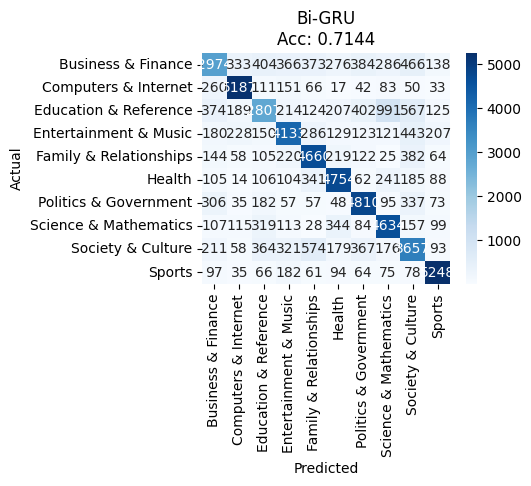

                        precision    recall  f1-score   support

    Business & Finance       0.63      0.50      0.55      6000
  Computers & Internet       0.83      0.86      0.85      6000
 Education & Reference       0.61      0.47      0.53      6000
 Entertainment & Music       0.71      0.69      0.70      6000
Family & Relationships       0.71      0.78      0.74      5999
                Health       0.76      0.79      0.78      6000
 Politics & Government       0.74      0.80      0.77      6000
 Science & Mathematics       0.69      0.77      0.73      6000
     Society & Culture       0.58      0.61      0.59      6000
                Sports       0.85      0.87      0.86      6000

              accuracy                           0.71     59999
             macro avg       0.71      0.71      0.71     59999
          weighted avg       0.71      0.71      0.71     59999



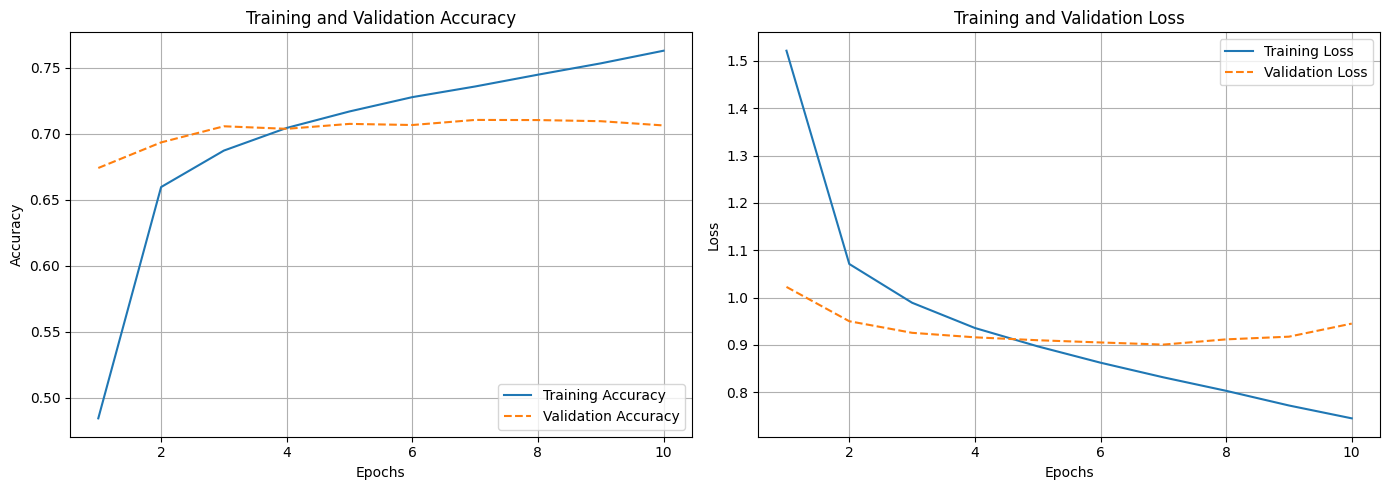

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import numpy as np
preds = model_bigru_opt.predict(X_test_seq)
dnn_pred = np.argmax(preds, axis=1)

cm = confusion_matrix(y_test, dnn_pred)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=le.classes_, yticklabels=le.classes_)
name="Bi-GRU"
plt.title(f"{name}\nAcc: {acc_gru:.4f}")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


classificationn_report = classification_report(y_test, dnn_pred, target_names=le.classes_)
print(classificationn_report)
import matplotlib.pyplot as plt

def plot_training_history(history):
    # Extract values from the history object
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    # Set up the figure
    plt.figure(figsize=(14, 5))

    # 1. Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linestyle='--')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    # 2. Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss', linestyle='--')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Run the plotting function
plot_training_history(history_bigru_1)

In [ ]:
accc=[acc_bigru_1,acc_gru]
accc.sort()
prediction["Bi-GRU"]=accc[-1]
prediction


{'logisticRegression': 0.6747112451874198,
 'DNN (TF-IDF)': 0.6709612011909485,
 'DNN': 0.6890948414802551,
 'RNN': 0.527675449848175,
 'GRU': 0.7026616930961609,
 'LSTM': 0.6929782032966614,
 'Bi-RNN': 0.5946599245071411,
 'Bi-GRU': 0.7144119143486023}

In [ ]:
# prediction={'logisticRegression': 0.6747112451874198,
#  'DNN (TF-IDF)': 0.6690945029258728,
#  'DNN': 0.6476607943465724,
#  'RNN': 0.44625744223594666,
#  'GRU': 0.7020283937454224,
#  'LSTM': 0.6952115893363953,
#  'Bi-RNN': 0.6005433201789856,
#  'Bi-GRU': 0.713611900806427}

Bi-LSTM

In [ ]:
#hp tuning 1
tf.keras.backend.clear_session()
HP1 = {
    'epochs': 15,
    'batch_size': 128,        # Increased batch size for stable updates
    'rnn_units': 128,         # Doubled neurons (64 -> 128)
    'dropout_rate': 0.3,
    'dense_units': 128,
    'patience': 4
}

# Define Early Stopping
early_stop_1 = EarlyStopping(monitor='val_loss', patience=HP1['patience'], restore_best_weights=True)
model_bilstm_1 = Sequential([
    Embedding(vocab_size, 100, weights=[matrix_skip], input_length=200, trainable=True),
    SpatialDropout1D(HP1['dropout_rate']),
    Bidirectional(LSTM(HP1['rnn_units'], dropout=HP1['dropout_rate'])),
    Dense(HP1['dense_units'], activation='relu'),
    Dropout(0.3),
    Dense(len(le.classes_), activation='softmax')
])

model_bilstm_1.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history_bilstm=model_bilstm_1.fit(X_train_seq, y_train,
                   epochs=HP1['epochs'], batch_size=HP1['batch_size'],
                   validation_split=0.1, callbacks=[early_stop_1], verbose=1)

# EVALUATE & PRINT
model_bilstm_1.summary()
acc_bilstm_1 = model_bilstm_1.evaluate(X_test_seq, y_test, verbose=0)[1]
experiment_results['Tuned-1 Bi-LSTM'] = acc_bilstm_1
print(f"✅ Accuracy for Tuned Bi-LSTM: {acc_bilstm_1:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 36s 49ms/step - accuracy: 0.4396 - loss: 1.6513 - val_accuracy: 0.6742 - val_loss: 1.0566
Epoch 2/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 32s 48ms/step - accuracy: 0.6502 - loss: 1.1121 - val_accuracy: 0.6932 - val_loss: 0.9558
Epoch 3/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 32s 48ms/step - accuracy: 0.6875 - loss: 0.9979 - val_accuracy: 0.7038 - val_loss: 0.9328
Epoch 4/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 31s 47ms/step - accuracy: 0.7080 - loss: 0.9270 - val_accuracy: 0.7072 - val_loss: 0.9105
Epoch 5/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 31s 48ms/step - accuracy: 0.7230 - loss: 0.8817 - val_accuracy: 0.7108 - val_loss: 0.9159
Epoch 6/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 31s 47ms/step - accuracy: 0.7332 - loss: 0.8455 - val_accuracy: 0.7098 - val_loss: 0.9282
Epoch 7/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 31s 48ms/step - accuracy: 0.7431 - loss: 0.8064 - val_accuracy: 0.7063 - val_loss: 0.9273
Epoch 8/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 32s 48ms/step - accuracy: 0.7571 - loss: 0.7706 - 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 100)       │    28,394,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 200, 100)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       234,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,988,348 (328.02 MB)

 Trainable params: 28,662,782 (109.34 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 57,325,566 (218.68 MB)

✅ Accuracy for Tuned Bi-LSTM: 0.7086


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step


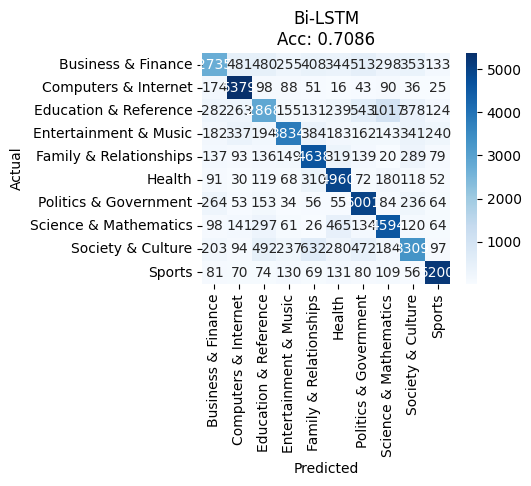

                        precision    recall  f1-score   support

    Business & Finance       0.64      0.46      0.53      6000
  Computers & Internet       0.77      0.90      0.83      6000
 Education & Reference       0.58      0.48      0.53      6000
 Entertainment & Music       0.77      0.64      0.70      6000
Family & Relationships       0.69      0.77      0.73      5999
                Health       0.71      0.83      0.76      6000
 Politics & Government       0.70      0.83      0.76      6000
 Science & Mathematics       0.68      0.77      0.72      6000
     Society & Culture       0.63      0.55      0.59      6000
                Sports       0.86      0.87      0.86      6000

              accuracy                           0.71     59999
             macro avg       0.70      0.71      0.70     59999
          weighted avg       0.70      0.71      0.70     59999



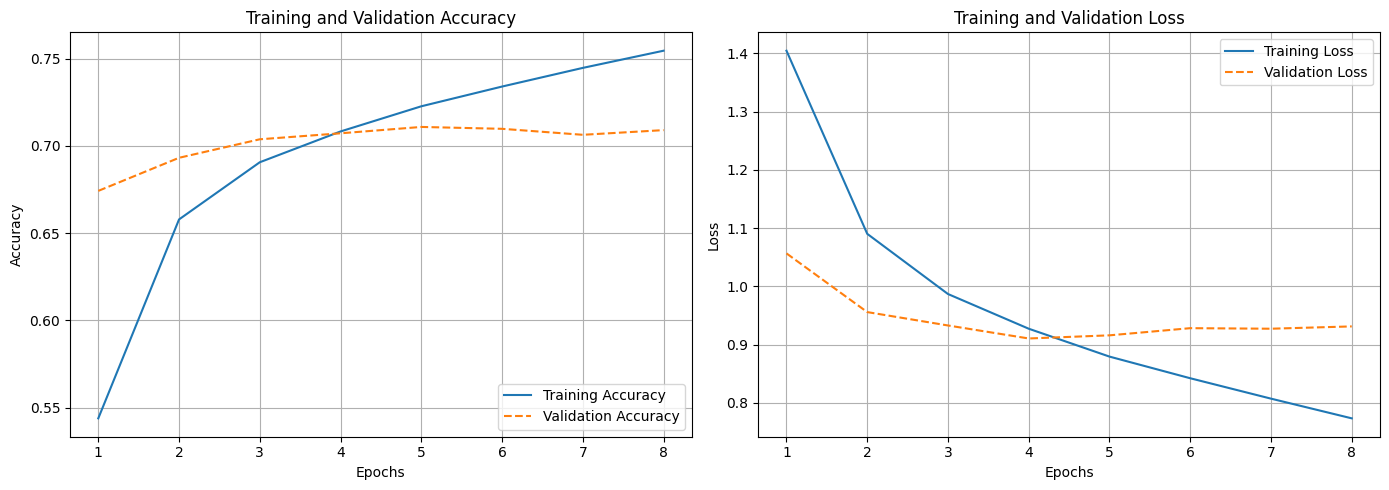

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import numpy as np
preds = model_bilstm_1.predict(X_test_seq)
dnn_pred = np.argmax(preds, axis=1)

cm = confusion_matrix(y_test, dnn_pred)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=le.classes_, yticklabels=le.classes_)
name="Bi-LSTM"
plt.title(f"{name}\nAcc: {acc_bilstm_1:.4f}")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


classificationn_report = classification_report(y_test, dnn_pred, target_names=le.classes_)
print(classificationn_report)
import matplotlib.pyplot as plt

def plot_training_history(history):
    # Extract values from the history object
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    # Set up the figure
    plt.figure(figsize=(14, 5))

    # 1. Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linestyle='--')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    # 2. Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss', linestyle='--')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Run the plotting function
plot_training_history(history_bilstm)

In [ ]:
#hp tuning 2
tf.keras.backend.clear_session()
HP_LSTM = {
    'epochs': 20,
    'batch_size': 512,      # INCREASED: 128 -> 512 (Massive speedup)
    'rnn_units': 100,
    'lr': 0.001
}

early_stop_lstm = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model_bilstm_opt = Sequential([
    Embedding(vocab_size, 100, weights=[matrix_skip], input_length=200, trainable=True),

    # INCREASED to 0.4 to compensate for removing internal dropout
    SpatialDropout1D(0.4),

    # REMOVED internal dropout (dropout=0)
    # This enables the "CuDNN Fast Path" which is ~10x faster on GPU
    Bidirectional(LSTM(HP_LSTM['rnn_units'])),

    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(len(le.classes_), activation='softmax')
])

model_bilstm_opt.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(learning_rate=HP_LSTM['lr']), metrics=['accuracy'])

history_bilstm_1= model_bilstm_opt.fit(
    X_train_seq, y_train,
    epochs=HP_LSTM['epochs'], batch_size=HP_LSTM['batch_size'],
    validation_split=0.1, callbacks=[early_stop_lstm], verbose=1
)

# Evaluate and Print immediately
acc_lstm = model_bilstm_opt.evaluate(X_test_seq, y_test, verbose=0)[1]
experiment_results['9. Optimized Bi-LSTM'] = acc_lstm
print(f"✅ FINAL ACCURACY (Bi-LSTM): {acc_lstm:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 18s 96ms/step - accuracy: 0.3658 - loss: 1.8294 - val_accuracy: 0.6666 - val_loss: 1.0725
Epoch 2/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 16s 95ms/step - accuracy: 0.6265 - loss: 1.1911 - val_accuracy: 0.6902 - val_loss: 1.0004
Epoch 3/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 16s 94ms/step - accuracy: 0.6623 - loss: 1.0843 - val_accuracy: 0.6908 - val_loss: 0.9809
Epoch 4/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 15s 93ms/step - accuracy: 0.6819 - loss: 1.0255 - val_accuracy: 0.7002 - val_loss: 0.9473
Epoch 5/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 15s 93ms/step - accuracy: 0.6993 - loss: 0.9755 - val_accuracy: 0.7046 - val_loss: 0.9278
Epoch 6/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 15s 93ms/step - accuracy: 0.7133 - loss: 0.9252 - val_accuracy: 0.7087 - val_loss: 0.9210
Epoch 7/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 16s 95ms/step - accuracy: 0.7188 - loss: 0.8973 - val_accuracy: 0.7112 - val_loss: 0.9092
Epoch 8/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 16s 94ms/step - accuracy: 0.7306 - loss: 0.8600 - 

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step


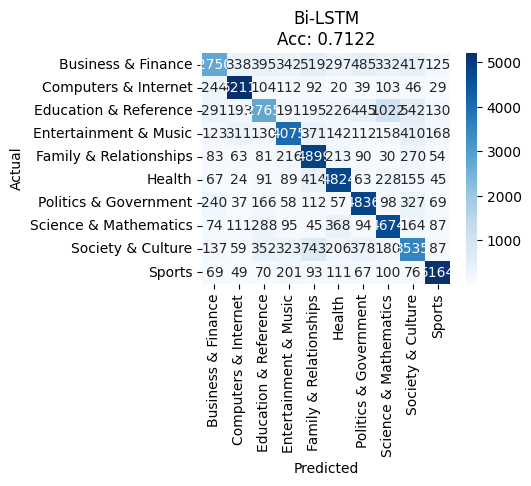

                        precision    recall  f1-score   support

    Business & Finance       0.67      0.46      0.55      6000
  Computers & Internet       0.81      0.87      0.84      6000
 Education & Reference       0.62      0.46      0.53      6000
 Entertainment & Music       0.71      0.68      0.70      6000
Family & Relationships       0.65      0.82      0.73      5999
                Health       0.75      0.80      0.77      6000
 Politics & Government       0.73      0.81      0.77      6000
 Science & Mathematics       0.67      0.78      0.72      6000
     Society & Culture       0.59      0.59      0.59      6000
                Sports       0.87      0.86      0.86      6000

              accuracy                           0.71     59999
             macro avg       0.71      0.71      0.71     59999
          weighted avg       0.71      0.71      0.71     59999



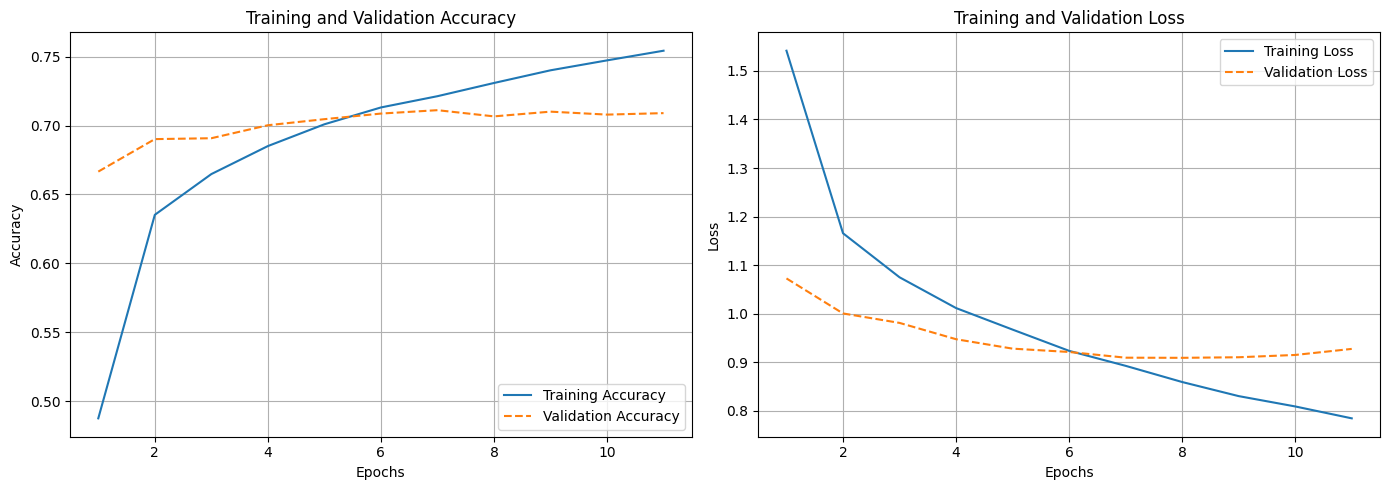

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import numpy as np
preds = model_bilstm_opt.predict(X_test_seq)
dnn_pred = np.argmax(preds, axis=1)

cm = confusion_matrix(y_test, dnn_pred)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=le.classes_, yticklabels=le.classes_)
name="Bi-LSTM"
plt.title(f"{name}\nAcc: {acc_lstm:.4f}")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


classificationn_report = classification_report(y_test, dnn_pred, target_names=le.classes_)
print(classificationn_report)
import matplotlib.pyplot as plt

def plot_training_history(history):
    # Extract values from the history object
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    # Set up the figure
    plt.figure(figsize=(14, 5))

    # 1. Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linestyle='--')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    # 2. Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss', linestyle='--')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Run the plotting function
plot_training_history(history_bilstm_1)

In [ ]:
accc=[acc_bilstm_1,acc_lstm]
accc.sort()
prediction["Bi-LSTM"]=accc[-1]
prediction


{'logisticRegression': 0.6747112451874198,
 'DNN (TF-IDF)': 0.6709612011909485,
 'DNN': 0.6890948414802551,
 'RNN': 0.527675449848175,
 'GRU': 0.7026616930961609,
 'LSTM': 0.6929782032966614,
 'Bi-RNN': 0.5946599245071411,
 'Bi-GRU': 0.7144119143486023,
 'Bi-LSTM': 0.712228536605835}

#Results

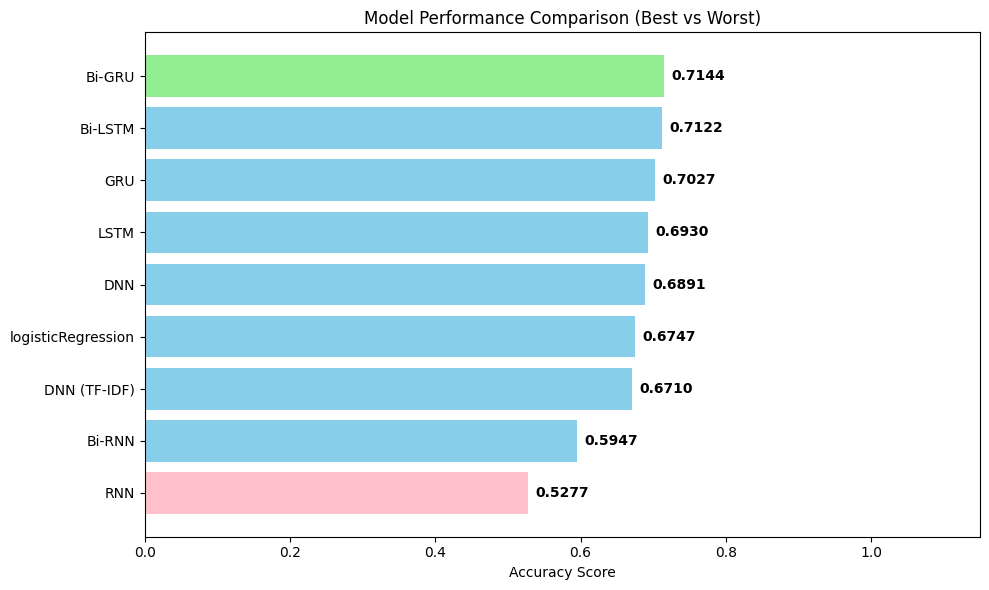

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Convert dictionary to DataFrame for easier handling
# Replace 'prediction' with your actual dictionary variable
df = pd.DataFrame(list(prediction.items()), columns=['Model', 'Accuracy'])

# 2. Sort by Accuracy (Ascending)
# This puts the "Worst" at the top (index 0) or bottom depending on orientation.
# Here we sort ascending so the highest value is last.
df = df.sort_values(by='Accuracy', ascending=True)

# 3. Create Custom Colors
# Initialize all bars with a neutral color (e.g., Sky Blue)
colors = ['skyblue'] * len(df)

# Highlight Worst Performer (First item after sorting) in Red
colors[0] = 'pink'

# Highlight Best Performer (Last item after sorting) in Green
colors[-1] = 'lightgreen'

# 4. Generate Plot
plt.figure(figsize=(10, 6))
bars = plt.barh(df['Model'], df['Accuracy'], color=colors)

# Formatting
plt.xlabel('Accuracy Score')
plt.title('Model Performance Comparison (Best vs Worst)')
plt.xlim(0, 1.15) # Extend x-axis slightly to fit text labels

# 5. Add Text Labels on Bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01,              # X position (just after the bar)
             bar.get_y() + bar.get_height()/2, # Y position (center of bar)
             f'{width:.4f}',            # Text Value
             va='center', fontweight='bold')

plt.tight_layout()
plt.show()